# GTSRB - German Traffic Sign Recognition Benchmark

- *Alex Martins*: PG61508
- *Miguel Machado*: PG60284
- *Paulo Ferreira*: PG60288


## Project Overview
This project aims to develop a high-accuracy deep learning model for classifying traffic signs from the GTSRB dataset. The dataset consists of 43 different classes of traffic signs, ranging from speed limits to warning signs (00000 - 00042).

## Objectives
- Explore data augmentation and image processing techniques.
- Build and evaluate several CNN architectures.
- Optimize performance to achieve similar to state-of-the-art results (Target: ~99.8%).

## Initial Setup and Documentation

### 1. Imports

<!-- **What:** --> 
We start by importing the standard libraries for deep learning, data manipulation, and visualization. We also add the `util` folder and the `src` folder to our path.
<!-- **Why:** --> 
These libraries provide the necessary tools for building and training neural networks (`torch`), handling images (`torchvision`, `PIL`), and visualizing data (`matplotlib`). Adding custom paths allows us to use project-specific helper functions.

In [11]:
import torch
import torchvision
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import shutil
import random
import time
from collections import Counter

# Add paths to import util and src modules
sys.path.append('util')
sys.path.append('../src')

import vcpi_util
import our_util

### 2. Device Configuration and Global Settings

<!-- **What:** -->
 We check for GPU availability using `torch.cuda.is_available()` and define all base paths and configuration parameters.

<!-- **Why** -->
GPUs can process large batches of data in parallel, making them much faster than CPUs for training neural networks. Defining a `device` variable allows us to write hardware-agnostic code.

#### Variable Documentation:
- `device`: (torch.device) The hardware used for training (CUDA if a GPU is detected, otherwise CPU).
- `RESET_DATASET_SPLIT`: (bool) When True, the validation split is recreated from the origin images.
- `RESET_DATASET_BALANCING`: (bool) When True, the training set is re-balanced.
- `PATH_ORIGINAL`: (str) Path to the untouched GTSRB training images.
- `PATH_TRAIN_ROOT`: (str) Path where the split training set (before balancing) is stored.
- `PATH_TRAIN_BALANCED`: (str) Path where the augmented and balanced training set is stored.
- `PATH_TEST`: (str) Path to the testing images.
- `PATH_VAL`: (str) Path to the validation images.
- `BATCH_SIZE`: (int) Number of samples per training step.
- `IMAGE_SIZE`: (int) Target resolution for all images (32x32).
- `AUGMENTATION_OPTIONS`: (dict) Configuration flags for the static balancing process.

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

RESET_DATASET_SPLIT = False
RESET_DATASET_BALANCING = False

PATH_ORIGINAL = '../datasets/original_train_images'
PATH_TRAIN_ROOT = '../datasets/train_images'
PATH_TRAIN_BALANCED = '../datasets/train_balanced'
PATH_TEST = '../datasets/test_images'
PATH_VAL = '../datasets/val_images'

BATCH_SIZE = 32
IMAGE_SIZE = 32
BALANCED_DATASET_SIZE = 2000

AUGMENTATION_OPTIONS = {
    'rotate': True,           # Rotates image between (-15°,15°)
    'affine': True,           # Applys transformations (translate and scale) 
    'color': True,            # Changes the image color (Brightness, contrast and saturation, DOES NOT CHANGES HUE)
    'perspective': True,      # Simulates a change in perspective
    'blur': True,             # Applys blur to the image (Simulates blur due to movement)
    'sharpness': False,       # Sharpens the image
    'grayscale': False,       # Applys grayscale (Not used because it may remove important features as colors)
    'noise': True,            # Applys noise (Smooth noise, similar to perlin noise)
}

print(f"Resetting dataset split is set to [{RESET_DATASET_SPLIT}]")
if RESET_DATASET_SPLIT:
    print("Resetting Dataset...")
    our_util.create_train_val_split(PATH_ORIGINAL, PATH_TRAIN_ROOT, PATH_VAL, 0.2)
else:
    print("Skipping Reset...")
    if not os.path.exists(PATH_TRAIN_ROOT) or not os.path.exists(PATH_VAL):
        our_util.create_train_val_split(PATH_ORIGINAL, PATH_TRAIN_ROOT, PATH_VAL, 0.2)

Using device: cuda
Resetting dataset split is set to [False]
Skipping Reset...


### 3. Loading the Datasets

<!-- **What:** -->
We load the datasets using `torchvision.datasets.ImageFolder`.

<!-- **Why:** -->
`ImageFolder` is an efficient way to load images organized in class-labeled folders. We apply a basic `Resize` and `ToTensor` transform to prepare the data for the model.

**Variable Documentation:**
- `transform`: (Compose) The list of transformations applied to every image upon loading (Resize + ToTensor).

In [13]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

train_set = datasets.ImageFolder(root=PATH_TRAIN_ROOT, transform=transform)
val_set = datasets.ImageFolder(root=PATH_VAL, transform=transform)
test_set = datasets.ImageFolder(root=PATH_TEST, transform=transform)

print(f"Original Training samples: {len(train_set)}")
print(f"Validation samples: {len(val_set)}")
print(f"Testing samples: {len(test_set)}")

Original Training samples: 28753
Validation samples: 6594
Testing samples: 12630


### 4. Visual Inspection of Loaded Data

We display a grid of random samples from each of the main dataset splits.

This helps us confirm that the labels match the images and that the images were loaded correctly into our desired resolution.

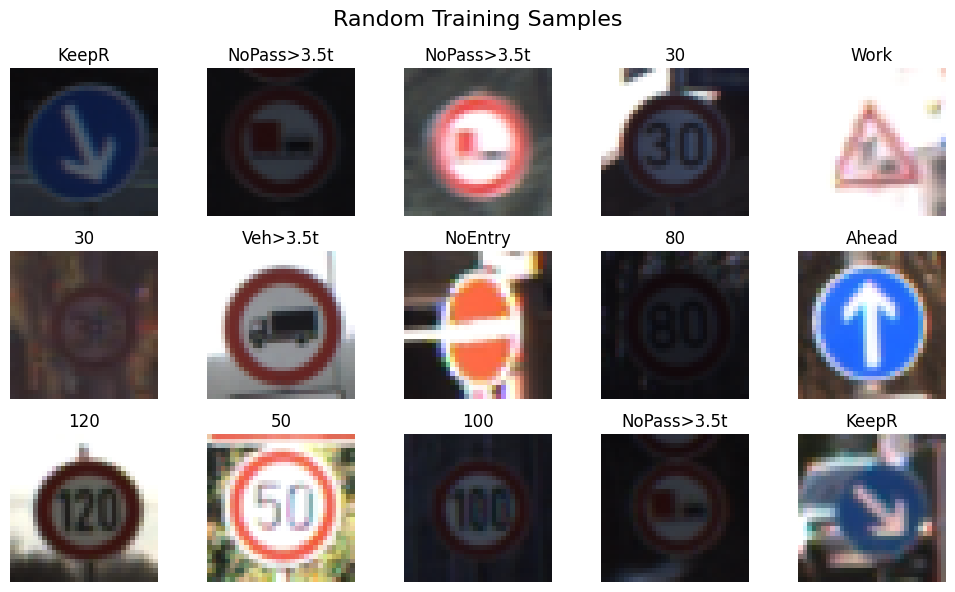

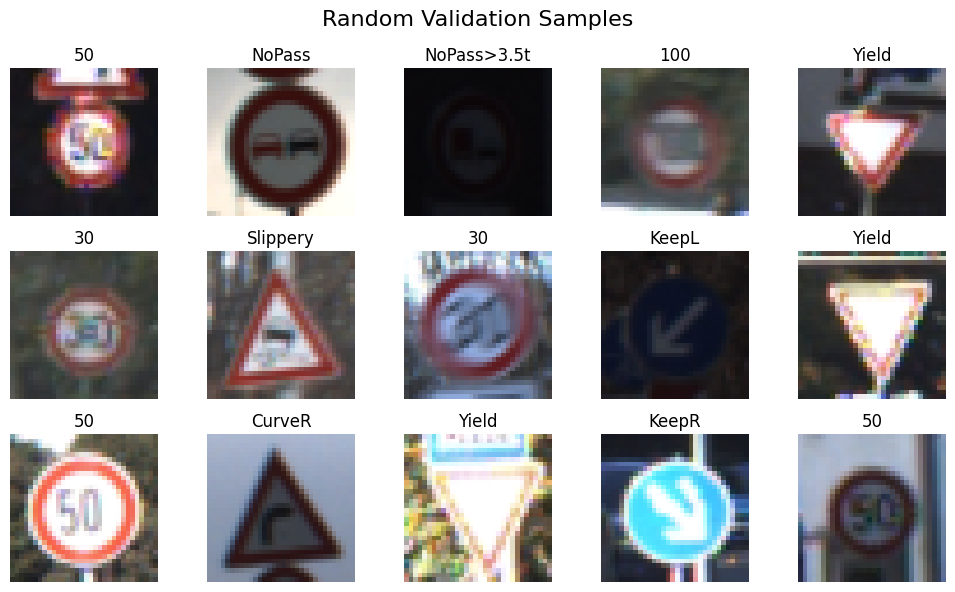

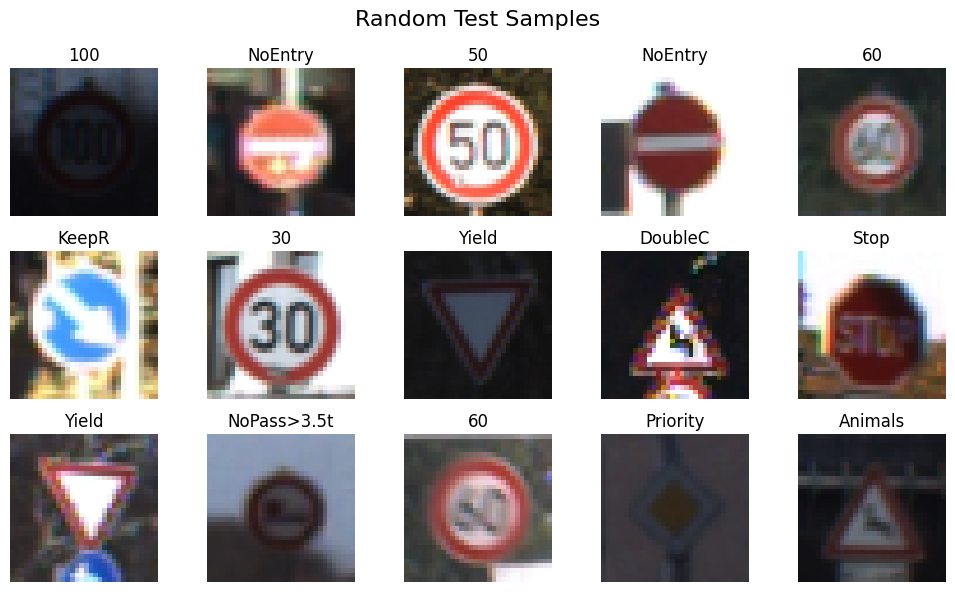

In [14]:
classes = [
    '20', '30', '50', '60', '70', '80', 'End80', '100', '120', 
    'NoPass', 'NoPass>3.5t', 'Inter', 'Priority', 'Yield', 
    'Stop', 'NoVeh', 'Veh>3.5t', 'NoEntry', 'GenC', 'CurveL', 
    'CurveR', 'DoubleC', 'Bumpy', 'Slippery', 'NarrowR', 'Work', 
    'Signals', 'Pedest', 'Children', 'Bicycles', 'Ice', 'Animals', 
    'EndLimits', 'TurnR', 'TurnL', 'Ahead', 'GoStR', 'GoStL', 
    'KeepR', 'KeepL', 'Roundabt', 'EndNoP', 'EndNoP>3.5t'
]

"""

classes = [
    '00', '01', '02', '03', '04', '05', '06', '07', '08', 
    '09', '10', '11', '12', '13', 
    '14', '15', '16', '17', '18', '19', 
    '20', '21', '22', '23', '24', '25', 
    '26', '27', '28', '29', '30', '31', 
    '32', '33', '34', '35', '36', '37', 
    '38', '39', '40', '41', '42'
]
"""

our_util.show_random_samples(train_set, classes, "Random Training Samples")
our_util.show_random_samples(val_set, classes, "Random Validation Samples")
our_util.show_random_samples(test_set, classes, "Random Test Samples")

### 5. Class Distribution Analysis

We use histograms to visualize the number of samples available for each traffic sign class.

Analyzing this distribution is a critical diagnostic step, as severe class imbalance naturally biases the neural network towards the majority classes during training. Consequently, the model struggles to extract robust and generalized features for the underrepresented minority classes, often leading to high overall accuracy but poor recall on rare signs. This visualization quantitatively exposes the dataset's imbalance, providing a clear justification for the data augmentation and balancing procedures implemented in Phase 2.

Analyzing Training Set distribution:
Counter({1: 1624, 2: 1607, 13: 1568, 38: 1524, 12: 1499, 10: 1481, 4: 1428, 5: 1352, 9: 1082, 25: 1080, 7: 1076, 8: 1038, 3: 1032, 11: 950, 18: 867, 35: 862, 17: 810, 14: 575, 31: 553, 33: 504, 15: 461, 26: 433, 28: 413, 23: 387, 6: 329, 30: 329, 34: 329, 16: 322, 36: 293, 22: 292, 20: 269, 40: 268, 21: 243, 39: 223, 24: 212, 29: 206, 42: 188, 32: 187, 41: 184, 27: 182, 19: 168, 0: 162, 37: 161})


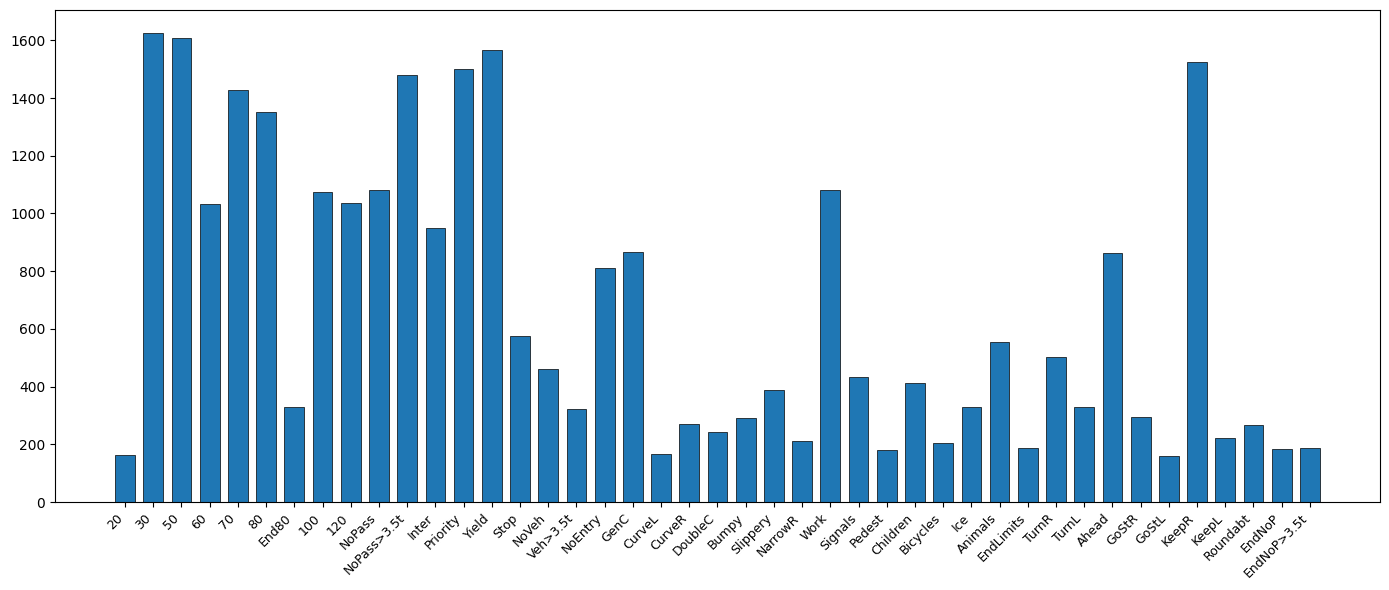

Analyzing Validation Set distribution:
Counter({2: 409, 1: 389, 13: 382, 12: 375, 4: 353, 10: 346, 38: 345, 5: 336, 25: 278, 9: 248, 7: 247, 3: 246, 8: 243, 18: 218, 35: 215, 11: 213, 17: 191, 31: 134, 14: 133, 15: 110, 26: 109, 33: 109, 23: 86, 28: 81, 30: 80, 20: 56, 6: 55, 21: 54, 40: 53, 16: 52, 34: 52, 36: 52, 22: 51, 39: 51, 37: 30, 19: 28, 24: 28, 42: 28, 32: 27, 0: 26, 29: 26, 27: 25, 41: 24})


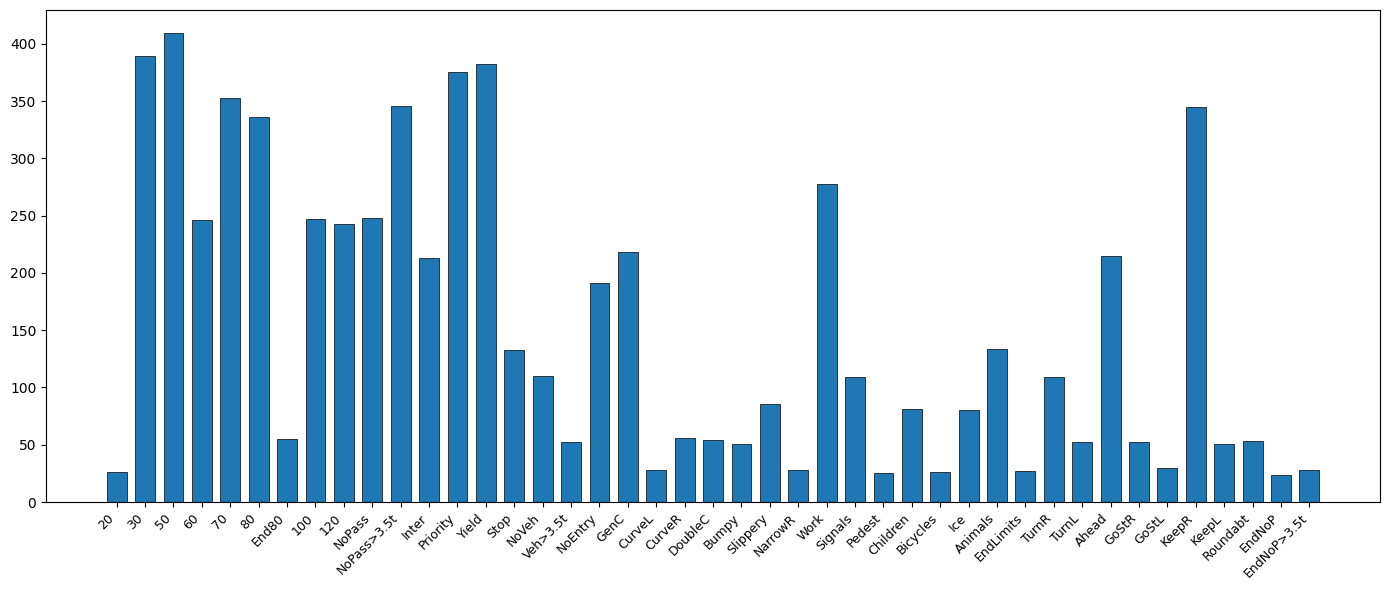

In [15]:
print("Analyzing Training Set distribution:")
train_targets_tensors = [torch.tensor(x) for x in train_set.targets]
vcpi_util.show_histogram(train_targets_tensors, classes)

print("Analyzing Validation Set distribution:")
val_targets_tensors = [torch.tensor(x) for x in val_set.targets]
vcpi_util.show_histogram(val_targets_tensors, classes)

# Phase 2: Data Balancing & Augmentation

To address the class imbalance identified in the previous phase, we apply targeted, static data augmentation to the minority classes, establishing a baseline threshold of 2000 samples per class (can be changed at the top of the file).

The augmentation pipeline is specifically engineered to simulate the real-world optical and physical conditions captured by a moving vehicle's camera, deliberately avoiding artificial filter that would destroy the semantic value of the traffic signs. This filters also have in consideration the test dataset, by trying to simulate conditions seen in the latter in the images from the train dataset. 

#### Applied Transformations (Simulating Real-World Conditions)
* **Random Rotation ($\pm15^\circ$):** Simulates the vehicle's suspension roll during cornering or signs that are physically misaligned on their posts.
* **Affine Shifts (Translation & Scale):** Mimics the varying distances of the car approaching the sign (scaling) and off-center camera framing due to road bumps (translation).
* **Color Jitter (Brightness, Contrast, Saturation):** Replicates dynamic weather and lighting conditions, such as driving against the sun, overcast skies, or shadows. The fundamental *hue* is explicitly preserved to maintain the semantic integrity of regulatory colors.
* **Perspective Distortion:** Simulates the oblique viewing angles that occur when the vehicle is navigating in adjacent lanes, rather than being perfectly aligned with the signpost.
* **Gaussian Blur:** Introduces simulated motion blur inherent to high-speed driving and engine vibrations.
* **Smooth Spatial Noise (Perlin Approximation):** Emulates low-frequency environmental artifacts such as localized lens dirt, fog patches, or uneven tree shadows across the sign's surface.

#### Excluded Transformations (Deliberately Omitted)
To prevent the model from learning corrupted or invalid representations of the GTSRB dataset, the following transformations were strictly disabled:
* **Grayscale Conversion (`grayscale: False`):** Color carries critical semantic weight in traffic regulations (e.g., red borders for prohibition/danger, solid blue for mandatory actions). Removing color destroys a primary classification feature.
* **Artificial Sharpening (`sharpness: False`):** Digital sharpening introduces high-contrast pixel artifacts that do not organically occur in vehicular cameras, conflicting with the realistic blur and noise regularization methods applied.
* **Horizontal Flip:** Never applied to traffic sign datasets. Flipping a sign horizontally alters its physical meaning (e.g., turning a "Keep Right" sign into an invalid "Keep Left" sign) without updating its label, which would severely confuse the network.

Re-Balancing dataset split is set to [False]
Skipping Re-Balancing...
Balanced Training samples: 86000
Analyzing Balanced Training Set distribution:
Counter({0: 2000, 1: 2000, 2: 2000, 3: 2000, 4: 2000, 5: 2000, 6: 2000, 7: 2000, 8: 2000, 9: 2000, 10: 2000, 11: 2000, 12: 2000, 13: 2000, 14: 2000, 15: 2000, 16: 2000, 17: 2000, 18: 2000, 19: 2000, 20: 2000, 21: 2000, 22: 2000, 23: 2000, 24: 2000, 25: 2000, 26: 2000, 27: 2000, 28: 2000, 29: 2000, 30: 2000, 31: 2000, 32: 2000, 33: 2000, 34: 2000, 35: 2000, 36: 2000, 37: 2000, 38: 2000, 39: 2000, 40: 2000, 41: 2000, 42: 2000})


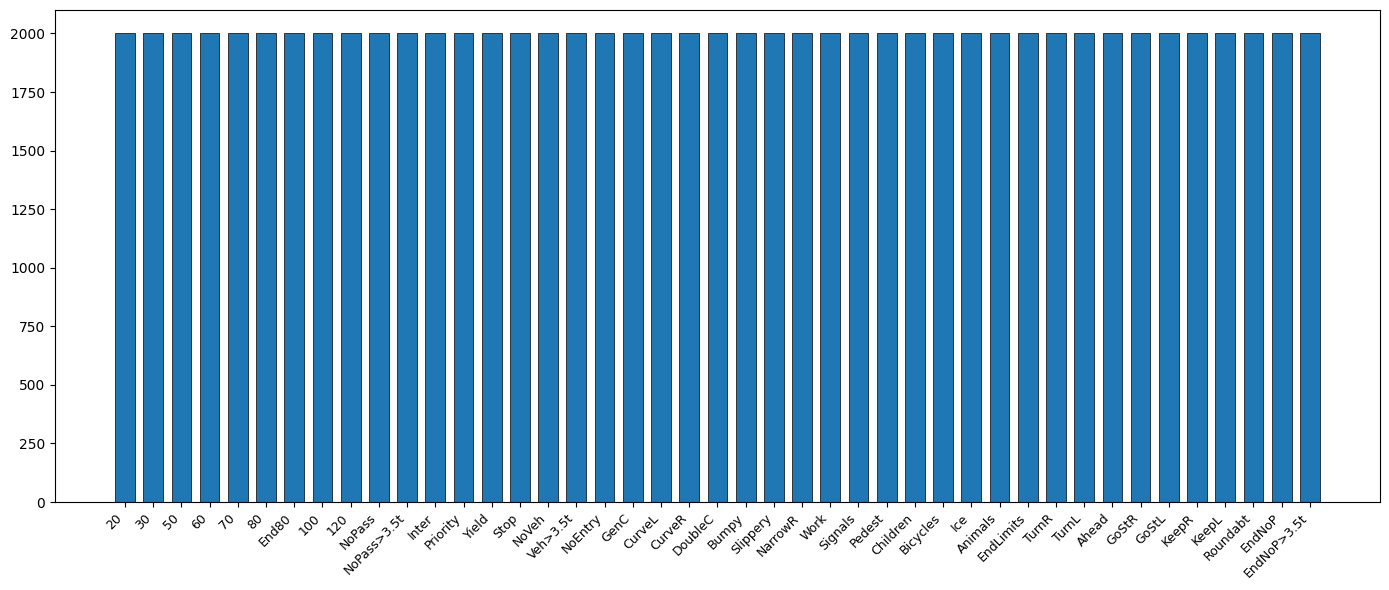

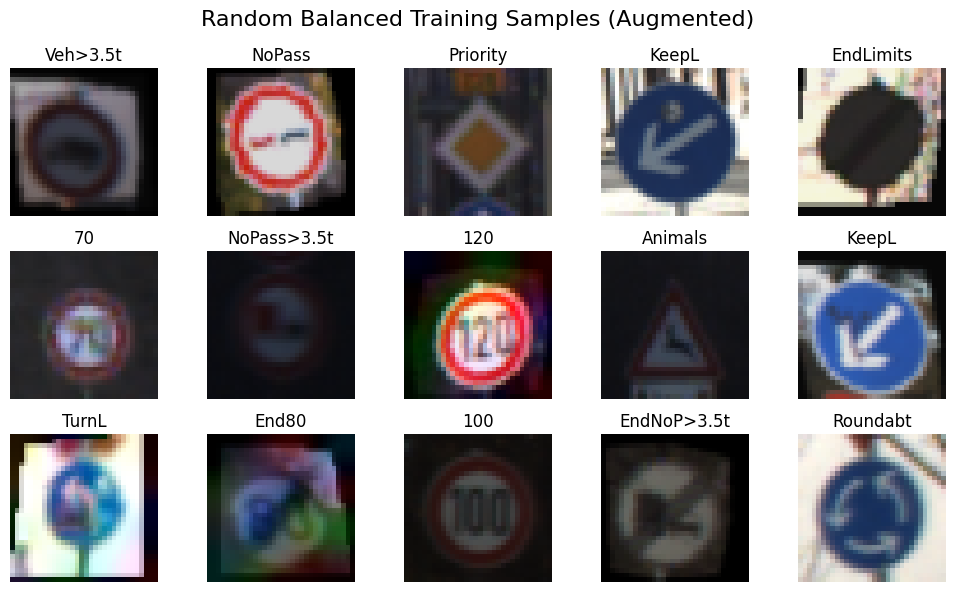

In [16]:
print(f"Re-Balancing dataset split is set to [{RESET_DATASET_BALANCING}]")
if RESET_DATASET_BALANCING:
    print("Re-Balancing Dataset...")
    our_util.create_train_val_split(PATH_ORIGINAL, PATH_TRAIN_ROOT, PATH_VAL, 0.2)
else:
    print("Skipping Re-Balancing...")
    if not os.path.exists(PATH_TRAIN_BALANCED):
        our_util.balance_dataset(PATH_TRAIN_ROOT, PATH_TRAIN_BALANCED, target_count=BALANCED_DATASET_SIZE, options=AUGMENTATION_OPTIONS)

train_set_balanced = datasets.ImageFolder(root=PATH_TRAIN_BALANCED, transform=transform)
print(f"Balanced Training samples: {len(train_set_balanced)}")

print("Analyzing Balanced Training Set distribution:")
train_balanced_targets_tensors = [torch.tensor(x) for x in train_set_balanced.targets]
vcpi_util.show_histogram(train_balanced_targets_tensors, classes)

our_util.show_random_samples(train_set_balanced, classes, "Random Balanced Training Samples (Augmented)")

# Phase 3: Model Development & Training

### 1. Training Infrastructure

We implemented a custom, modular training infrastructure to orchestrate the neural network's learning process. This encompasses a dedicated training loop (`train_model`) and an automated regularization mechanism (`Early_Stopping`).

A training loop is imperative for computational efficiency and optimal model convergence. It ensures seamless tensor transfers to hardware accelerators (GPU/CUDA), manages iterative gradient descent, and dynamically evaluates the model on unseen validation data at the end of each epoch. Crucially, the integration of an Early Stopping mechanism acts as a dynamic regularizer; it halts the training process exactly when the model transitions from learning generalized features to memorizing the training set, thereby preventing severe overfitting.

#### Infrastructure Components & Mechanics:

* **`train_model` (Core Training Loop):** The primary orchestration function. It executes the forward pass, calculates the objective function (loss), performs backpropagation (`loss.backward()`), and updates the network weights via the optimizer. It strictly enforces the separation of `model.train()` and `model.eval()` modes, ensuring that stochastic layers (such as Dropout and Batch Normalization) behave correctly during validation inference. Furthermore, it records performance metrics for post-training visualization and integrates a learning rate scheduler to adaptively reduce step sizes upon plateauing.

* **`Early_Stopping` (Validation Monitor):** A programmatic callback class that continuously evaluates the validation loss against historical bests. It utilizes two key parameters: `patience` (the maximum number of consecutive epochs to tolerate without improvement) and `min_delta` (the minimum quantitative decrease in loss required to qualify as a valid improvement). If the validation loss plateaus or begins to diverge upward (indicating overfitting), this class interrupts the loop, saving computational time and preserving the weights of the most generalized model state.

In [17]:
class Early_Stopping():
    def __init__(self, patience = 5, min_delta = 0.00001):
        self.patience = patience 
        self.min_delta = min_delta
        self.min_val_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
        return False

def train_model(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, device, save_prefix = 'model'):
    history = {'accuracy': [], 'val_acc': [], 'val_loss': [], 'loss': []}
    best_val_loss = np.inf
    model.to(device)

    for epoch in range(epochs):
        model.train()
        start_time = time.time()
        correct = 0
        running_loss = 0.0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == targets).sum().item()

        model.eval()
        v_correct = 0
        v_running_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = loss_fn(outputs, targets)
                v_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                v_correct += (predicted == targets).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = 100 * correct / len(train_loader.dataset)
        v_epoch_loss = v_running_loss / len(val_loader.dataset)
        v_accuracy = 100 * v_correct / len(val_loader.dataset)
        
        scheduler.step(v_epoch_loss)
        
        history['accuracy'].append(accuracy)
        history['loss'].append(epoch_loss)
        history['val_acc'].append(v_accuracy)
        history['val_loss'].append(v_epoch_loss)
        
        elapsed = time.time() - start_time
        print(f'Epoch {epoch+1:03d}: Loss: {epoch_loss:.4f}, Acc: {accuracy:.2f}%, Val Loss: {v_epoch_loss:.4f}, Val Acc: {v_accuracy:.2f}%, Time: {elapsed:.2f}s')

        if v_epoch_loss < best_val_loss:
            best_val_loss = v_epoch_loss
            torch.save(model.state_dict(), f'{save_prefix}_best.pt')

        if early_stopper(v_epoch_loss):
            print('Early stopping triggered.')
            break
            
    return history

### 2. Baseline Architecture

As the initial step in our architectural exploration, we implemented a foundational Convolutional Neural Network (`BaselineCNN`) to serve as our experimental baseline. This is a low-capacity model comprising only two convolutional blocks and a single fully connected layer.

In empirical machine learning, establishing a baseline is a methodological step. This stripped-down architecture provides a critical lower-bound performance metric on the GTSRB dataset. By isolating the core convolutional operations without the aid of advanced regularizers (such as Dropout or Batch Normalization) or dynamic pooling strategies, we create a strict control model. Consequently, any subsequent architectural enhancements can be quantitatively validated against this baseline to unequivocally prove their efficacy.

#### Structural Breakdown:
* **Feature Extraction (`Conv2d` + `ReLU`):** Utilizes minimal filters (8 and 16 channels) to extract rudimentary visual features. The ReLU activation introduces the necessary non-linearity to learn hierarchical patterns.
* **Spatial Reduction (`MaxPool2d`):** Applied sequentially to halve the spatial dimensions of the feature maps, thereby reducing computational load and providing basic translational invariance.
* **Classification Head (`Flatten` + `Linear`):** Employs a static flattening operation that unrolls the 2D spatial tensors into a 1D vector. This feeds into a singular fully connected layer (`fc`) mapped to the dataset's target classes, producing the final raw logits for classification.

In [18]:
class BaselineCNN(torch.nn.Module):
    def __init__(self, num_classes, image_size):
        super().__init__()
        self.conv_layers = torch.nn.Sequential(
            torch.nn.Conv2d(3, 8, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2), # Halves the image size
            torch.nn.Conv2d(8, 16, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)  # Halves the image size again
        )
        
        # Calculate the spatial dimension after two MaxPool2d(2) layers
        final_spatial_dim = image_size // 4 
        
        # 16 is the number of output channels from the last Conv2d layer
        self.flattened_size = 16 * final_spatial_dim * final_spatial_dim
        
        self.fc = torch.nn.Linear(self.flattened_size, num_classes)

    def forward(self, x):
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

### 3. Hyperparameter Configuration and Execution

This phase operationalizes the network by defining the optimization strategy, the objective function, and the training lifecycle parameters. The model, along with its designated mathematical constraints, is then injected into the training loop for weight optimization.

Selecting the correct hyperparameter suite is as critical as the architecture itself for ensuring convergence. We implemented `CrossEntropyLoss` as it is the mathematical standard for multi-class classification, heavily penalizing confident but incorrect predictions. For gradient descent, the `Adam` (Adaptive Moment Estimation) optimizer was selected over standard SGD due to its computational efficiency and ability to individually adapt learning rates for each weight parameter based on first and second moments of gradients.

#### Optimization Variables & Mechanics:

* **`EPOCHS` (Training Bound):** Defines the theoretical upper bound of complete passes through the training dataset. The actual number of epochs is dynamically regulated by the `Early_Stopping` mechanism to prevent overfitting.
* **`LEARNING_RATE` (Initial Step Size):** The starting magnitude of the weight updates during gradient descent. It must be empirically balanced—too high causes the model to diverge, too low causes stagnation.
* **`optimizer` (torch.optim.Adam):** The primary engine for backpropagation. It leverages momentum to navigate the loss landscape efficiently, overcoming saddle points and accelerating early-stage convergence.
* **`scheduler` (ReduceLROnPlateau):** A dynamic decay mechanism crucial for fine-tuning. When the validation loss stops improving (plateaus), the scheduler drastically reduces the learning rate. This allows the optimizer to take micro-steps and settle into narrow local minima without overshooting the optimal weights.

In [19]:
print("\n--- STARTING BASELINE MODEL TRAINING ---")

EPOCHS = 30
LEARNING_RATE = 0.005

train_loader_balanced = torch.utils.data.DataLoader(train_set_balanced, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

model_baseline = BaselineCNN(len(classes), IMAGE_SIZE)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_baseline.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
early_stopper = Early_Stopping(patience=5)

history_baseline = train_model(
    model_baseline, 
    train_loader_balanced, 
    val_loader, 
    EPOCHS, 
    loss_fn, 
    optimizer, 
    scheduler, 
    early_stopper, 
    device, 
    save_prefix='baseline'
)


--- STARTING BASELINE MODEL TRAINING ---
Epoch 001: Loss: 1.9245, Acc: 47.46%, Val Loss: 0.7961, Val Acc: 79.92%, Time: 34.39s
Epoch 002: Loss: 1.3172, Acc: 63.75%, Val Loss: 0.7733, Val Acc: 78.86%, Time: 35.35s
Epoch 003: Loss: 1.1667, Acc: 67.50%, Val Loss: 0.6063, Val Acc: 83.00%, Time: 36.37s
Epoch 004: Loss: 1.0232, Acc: 71.38%, Val Loss: 0.4978, Val Acc: 86.53%, Time: 36.39s
Epoch 005: Loss: 0.9123, Acc: 74.40%, Val Loss: 0.5761, Val Acc: 85.20%, Time: 35.90s
Epoch 006: Loss: 0.8672, Acc: 75.42%, Val Loss: 0.5088, Val Acc: 87.90%, Time: 34.85s
Epoch 007: Loss: 0.8386, Acc: 76.37%, Val Loss: 0.4549, Val Acc: 88.11%, Time: 35.56s
Epoch 008: Loss: 0.8230, Acc: 76.68%, Val Loss: 0.4970, Val Acc: 86.94%, Time: 35.59s
Epoch 009: Loss: 0.8084, Acc: 77.11%, Val Loss: 0.4423, Val Acc: 88.60%, Time: 35.49s
Epoch 010: Loss: 0.7967, Acc: 77.34%, Val Loss: 0.4692, Val Acc: 88.26%, Time: 35.24s
Epoch 011: Loss: 0.7896, Acc: 77.61%, Val Loss: 0.4817, Val Acc: 87.26%, Time: 35.13s
Epoch 012: L

### 4. Empirical Training Evaluation (Learning Curves)

We utilize a 2x2 grid visualization to plot the trajectory of both loss and accuracy metrics across all training and validation epochs.

Visualizing learning curves is a fundamental diagnostic procedure in deep learning. It allows us to empirically verify model convergence and actively monitor the bias-variance tradeoff. By plotting the training and validation metrics simultaneously, we can visually identify the exact epoch where the model transitions from learning generalized features to memorizing the training data (overfitting)—typically indicated by a divergence where training loss continues to fall while validation loss plateaus or spikes. In our case study, we can observe that overfitting begins to manifest around epoch 17, where the validation loss plateaus while the training loss continues to approach zero.

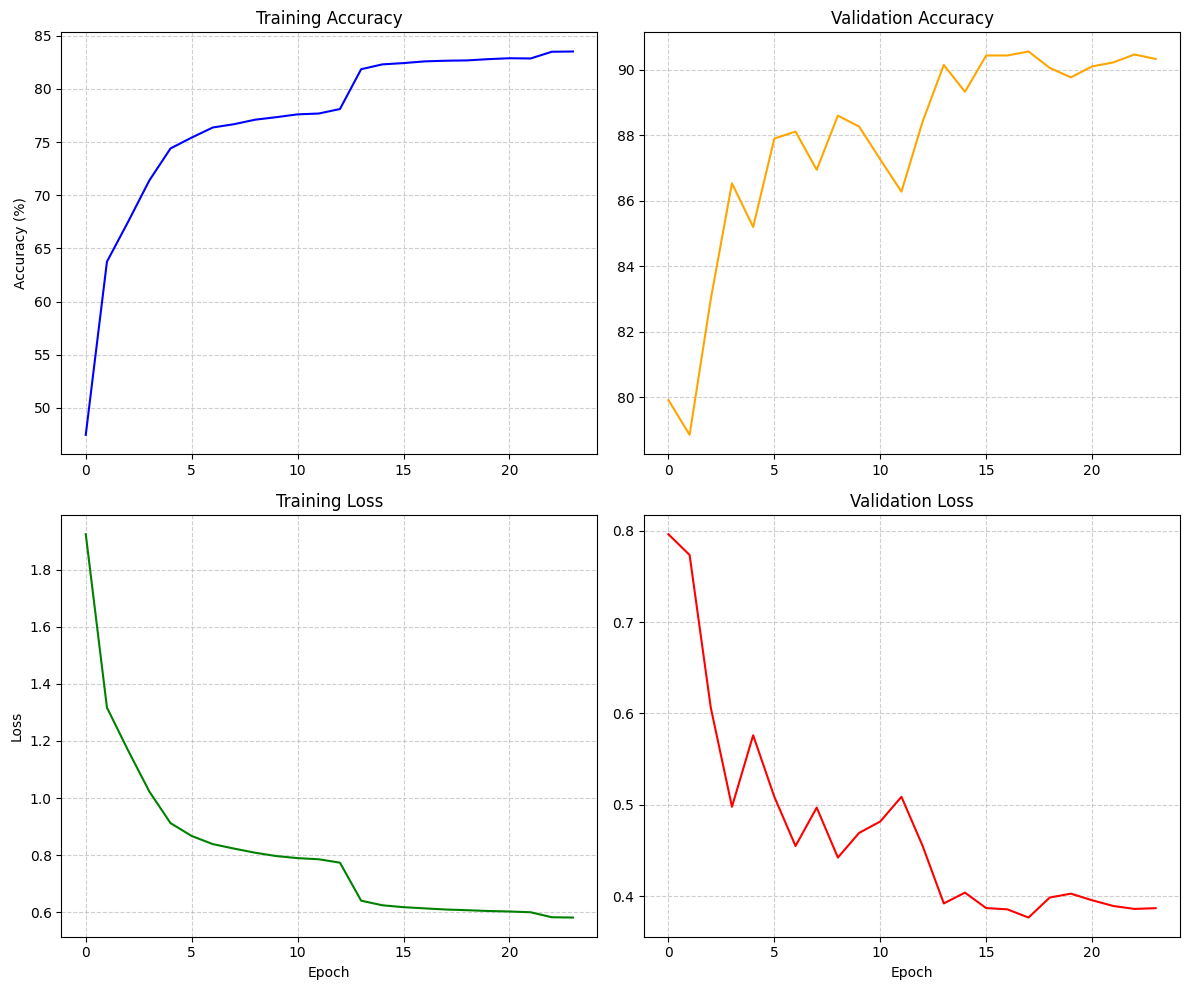

In [20]:
vcpi_util.show_history_2x2(history_baseline)

### 5. Final Benchmark: Test Set Evaluation

The model is subjected to a final inference pass using the Test Set. Crucially, we do not evaluate the model at its final epoch state; instead, we load the optimal weight checkpoint (`baseline_best.pt`) captured dynamically during training.

The test set acts as the ultimate empirical proxy for real-world deployment. Unlike the validation set, which implicitly influences the model via hyperparameter tuning, learning rate scheduling, and early stopping decisions—the test set remains entirely unseen. Evaluating the checkpointed optimal weights on this data ensures we are testing the network at its absolute peak generalization capacity, providing an unbiased and definitive metric of its true performance.

In [21]:
def evaluate_test_set(model, test_loader, device, weights_path):
    # Load the best weights
    model.load_state_dict(torch.load(weights_path))
    model.to(device)
    model.eval()
    
    all_preds = []
    all_targets = []
    correct = 0
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == targets).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
    test_accuracy = 100 * correct / len(test_loader.dataset)
    
    print(f"[TEST DATASET | CLASSIFICATION ACCURACY]: {test_accuracy:.2f}%")
    
    return all_targets, all_preds

test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print("\n--- INITIAL EVALUATION: BASELINE MODEL ---")
targets, preds = evaluate_test_set(model_baseline, test_loader, device, 'baseline_best.pt')


--- INITIAL EVALUATION: BASELINE MODEL ---


C:\Users\paulo\AppData\Local\Temp\ipykernel_36240\3101309227.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path))


[TEST DATASET | CLASSIFICATION ACCURACY]: 87.10%


# Phase 4: Architectural Optimization (Robust CNN)

To transcend the limitations of the baseline model, we engineered a high-capacity, robust Convolutional Neural Network (`RobustCNN`). This advanced architecture integrates modern regularization techniques and dynamic spatial pooling to successfully decode the high variance of the GTSRB dataset.

* **Increased Depth & Width (Channel Expansion):** We significantly expanded the convolutional capacity (scaling up to 128 output channels across three distinct blocks). This allows the network to extract a much richer, deeper hierarchy of semantic features, moving from simple edges in Block 1 to more complex features.
* **Batch Normalization (`BatchNorm2d`):** Applied immediately after every convolution, this normalizes the activation outputs for each mini-batch. It mitigates *internal covariate shift*, stabilizes the gradient flow, prevents vanishing/exploding gradients, and allows the optimizer to converge faster.
* **Stochastic Regularization (`Dropout`):** By randomly disabling a percentage of neurons (e.g., `p=0.5`) during each forward pass, we prevent complex co-adaptations between specific neurons. This forces the network to learn redundant, robust feature representations rather than memorizing the exact pixel structures of the training images.
* **Global Average Pooling (GAP):** We replaced the rigid, highly parameterized `Flatten` operation with a `torch.mean` reduction across spatial dimensions. GAP averages each 2D feature map into a single scalar. This drastic reduction in the dense layer's parameter count is one of the most effective ways to prevent overfitting. Furthermore, it inherently grants the network structural invariance to spatial translations, meaning the model can recognize a traffic sign regardless of exactly where it appears in the frame.

In [22]:
class RobustCNN(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # Bloco 1: Baixo nível (extração de formas básicas)
        self.block1 = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, 32, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)
        )
        
        # Bloco 2: Médio nível (padrões complexos)
        self.block2 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.Conv2d(64, 64, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)
        )

        # Bloco 3: Alto nível (semântica do sinal)
        self.block3 = torch.nn.Sequential(
            torch.nn.Conv2d(64, 128, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)
        )
        
        self.dropout = torch.nn.Dropout(p=0.5)
        self.fc = torch.nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        
        # Global Average Pooling (GAP) - Reduz as matrizes espaciais a escalares
        x = torch.mean(x, dim=[2, 3])
        
        x = self.dropout(x)
        x = self.fc(x)
        return x

### 1. Robust Model Execution and Evaluation

With the architectural enhancements defined, we instantiate the `RobustCNN` and proceed to the training phase. Prior to execution, all training mechanisms—including the Adam optimizer, the learning rate scheduler, and the Early Stopping monitor—are strictly re-initialized. This guarantees a sterile computational environment, preventing any gradient state leakage or momentum carryover from the baseline experiment.

#### Comparative Visual Analysis (Learning Curves)
Following the training loop, a 2x2 grid visualization is generated to dissect the network's learning trajectory. Unlike the baseline model, which typically exhibits rapid divergence between training and validation loss (a hallmark of memorization), the `RobustCNN` learning curves empirically validate our architectural choices:
* **Effect of Regularization:** The inclusion of Dropout and Global Average Pooling visibly delays the onset of overfitting, allowing the validation accuracy to closely track the training accuracy for a longer duration.
* **Effect of Batch Normalization:** The loss curve descends much more smoothly and stabilizes rapidly, proving that internal covariate shift has been mitigated and the gradient flow is stable.

#### The Ultimate Benchmark: Test Set Inference
To conclude the empirical evaluation, the `RobustCNN` is benchmarked against the Test Set. Consistent with our methodology, we do not evaluate the final epoch's state. Instead, we load the optimal weight checkpoint (`robust_best.pt`), which was dynamically saved at the exact epoch where validation loss reached its absolute minimum.

Comparing the Final Test Accuracy of the `RobustCNN` against the `BaselineCNN` provides quantifiable proof of the robust architecture. This network, coupled with our data augmentation strategy (Phase 2), yields a model that not only fits the training data but successfully generalizes to the chaotic, real-world variations present in unseen traffic signs.


--- STARTING ROBUST MODEL TRAINING ---
Epoch 001: Loss: 1.4480, Acc: 57.90%, Val Loss: 0.0627, Val Acc: 98.27%, Time: 38.33s
Epoch 002: Loss: 0.2046, Acc: 94.21%, Val Loss: 0.0465, Val Acc: 98.79%, Time: 37.33s
Epoch 003: Loss: 0.1323, Acc: 96.17%, Val Loss: 0.0601, Val Acc: 98.30%, Time: 37.91s
Epoch 004: Loss: 0.1049, Acc: 97.03%, Val Loss: 0.0152, Val Acc: 99.53%, Time: 37.72s
Epoch 005: Loss: 0.0853, Acc: 97.57%, Val Loss: 0.0160, Val Acc: 99.58%, Time: 37.71s
Epoch 006: Loss: 0.0741, Acc: 97.84%, Val Loss: 0.0189, Val Acc: 99.36%, Time: 38.15s
Epoch 007: Loss: 0.0660, Acc: 98.12%, Val Loss: 0.0138, Val Acc: 99.61%, Time: 37.34s
Epoch 008: Loss: 0.0593, Acc: 98.30%, Val Loss: 0.0293, Val Acc: 99.17%, Time: 38.24s
Epoch 009: Loss: 0.0533, Acc: 98.40%, Val Loss: 0.0262, Val Acc: 99.27%, Time: 37.62s
Epoch 010: Loss: 0.0484, Acc: 98.63%, Val Loss: 0.0163, Val Acc: 99.53%, Time: 37.60s
Epoch 011: Loss: 0.0457, Acc: 98.65%, Val Loss: 0.0114, Val Acc: 99.71%, Time: 37.81s
Epoch 012: Los

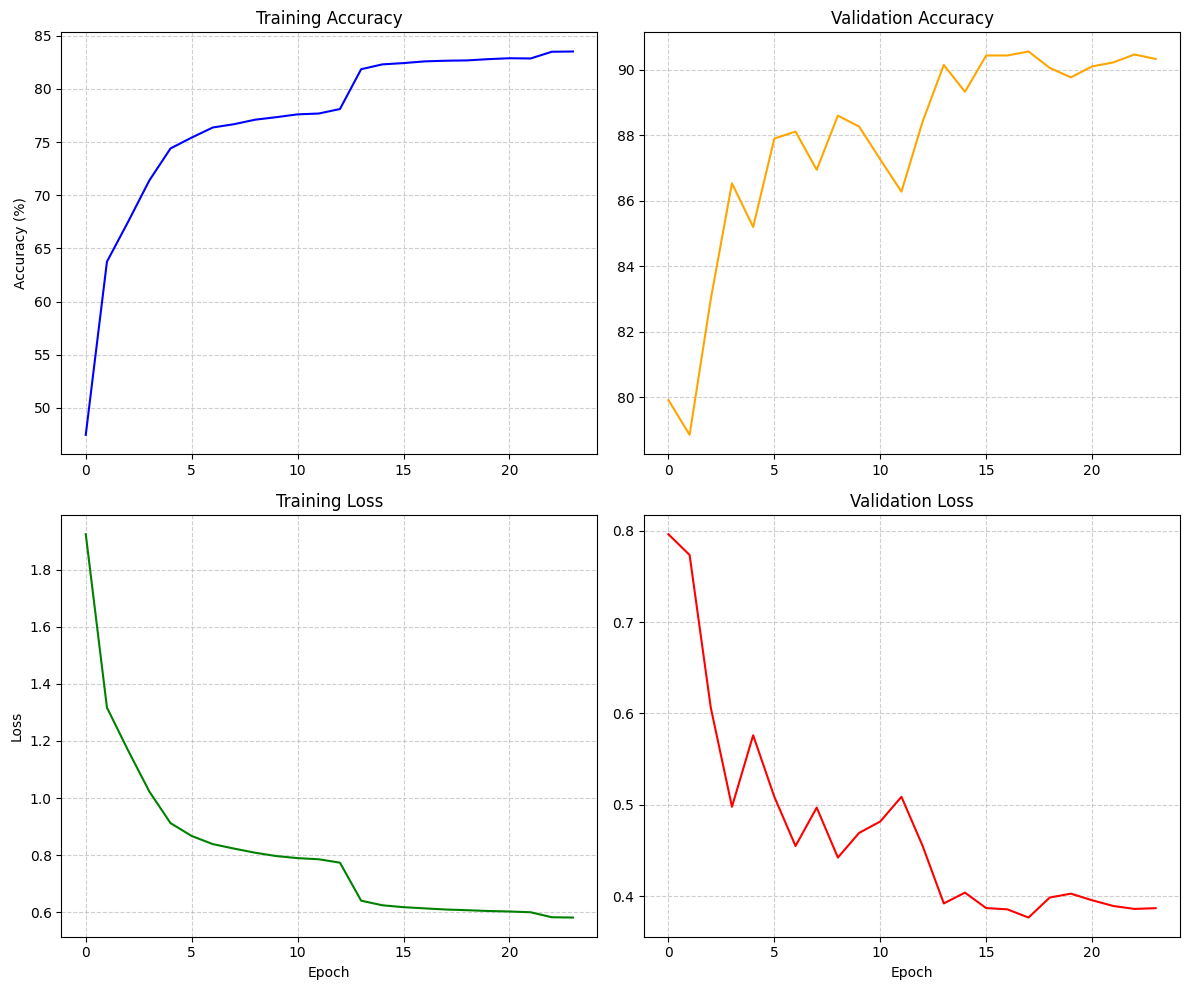


--- FINAL EVALUATION: ROBUST MODEL ---


C:\Users\paulo\AppData\Local\Temp\ipykernel_36240\3101309227.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path))


[TEST DATASET | CLASSIFICATION ACCURACY]: 99.35%


In [23]:
print("\n--- STARTING ROBUST MODEL TRAINING ---")

# 1. Instanciar a nova rede
# Nota: Já não precisas de passar o IMAGE_SIZE por causa do GAP
model_robust = RobustCNN(len(classes))

# 2. Reinicializar ferramentas de treino
optimizer_robust = torch.optim.Adam(model_robust.parameters(), lr=LEARNING_RATE)
scheduler_robust = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_robust, mode='min', factor=0.1, patience=3)
early_stopper_robust = Early_Stopping(patience=5)

# 3. Treinar
history_robust = train_model(
    model_robust, 
    train_loader_balanced, 
    val_loader, 
    EPOCHS, 
    loss_fn, 
    optimizer_robust, 
    scheduler_robust, 
    early_stopper_robust, 
    device, 
    save_prefix='robust'
)

# 4. Visualizar resultados do treino
vcpi_util.show_history_2x2(history_baseline)

# 5. Avaliar no Test Set com os melhores pesos guardados
print("\n--- FINAL EVALUATION: ROBUST MODEL ---")
targets_robust, preds_robust = evaluate_test_set(
    model_robust, 
    test_loader, 
    device, 
    'robust_best.pt'
)

## Dynamic Data Augmentation
**What:** In this section, we apply online data augmentation directly in the training pipeline.

**Why:** Unlike offline augmentation, where transformed images are generated once and saved to disk, dynamic augmentation applies random transformations every time an image is loaded during training. This increases data variability across epochs and can improve generalization.

**Important:** Dynamic augmentation is applied only to the training set. Validation and test sets keep deterministic preprocessing to ensure a fair evaluation.

In [24]:
dynamic_train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(12),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.08, 0.08),
        scale=(0.95, 1.05),
        shear=8
    ),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.3),
    transforms.ToTensor()
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

In [25]:
train_set_balanced_dynamic = datasets.ImageFolder(root=PATH_TRAIN_BALANCED, transform=dynamic_train_transform)
val_set_dynamic = datasets.ImageFolder(root=PATH_VAL, transform=eval_transform)
test_set_dynamic = datasets.ImageFolder(root=PATH_TEST, transform=eval_transform)

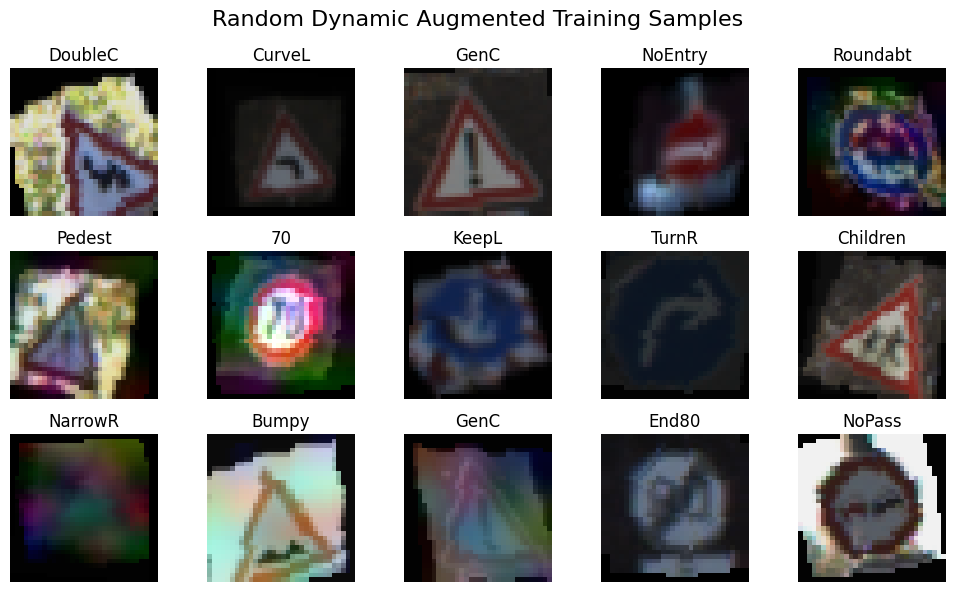

In [26]:
our_util.show_random_samples(train_set_balanced_dynamic, classes, "Random Dynamic Augmented Training Samples")

In [27]:
train_loader_balanced_dynamic = torch.utils.data.DataLoader(
    train_set_balanced_dynamic,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_dynamic = torch.utils.data.DataLoader(
    val_set_dynamic,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [28]:
model_dynamic = RobustCNN(len(classes))
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_dynamic.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=3
)
early_stopper = Early_Stopping(patience=5)

history_dynamic = train_model(
    model_dynamic,
    train_loader_balanced_dynamic,
    val_loader_dynamic,
    EPOCHS,
    loss_fn,
    optimizer,
    scheduler,
    early_stopper,
    device,
    save_prefix='baseline_dynamic'
)

Epoch 001: Loss: 1.8520, Acc: 45.26%, Val Loss: 0.1353, Val Acc: 95.47%, Time: 66.48s
Epoch 002: Loss: 0.3993, Acc: 88.50%, Val Loss: 0.0444, Val Acc: 98.64%, Time: 64.73s
Epoch 003: Loss: 0.2794, Acc: 92.01%, Val Loss: 0.0172, Val Acc: 99.41%, Time: 64.45s
Epoch 004: Loss: 0.2282, Acc: 93.50%, Val Loss: 0.0228, Val Acc: 99.41%, Time: 64.96s
Epoch 005: Loss: 0.1999, Acc: 94.29%, Val Loss: 0.0124, Val Acc: 99.59%, Time: 64.54s
Epoch 006: Loss: 0.1760, Acc: 94.97%, Val Loss: 0.0209, Val Acc: 99.33%, Time: 64.78s
Epoch 007: Loss: 0.1582, Acc: 95.37%, Val Loss: 0.0145, Val Acc: 99.47%, Time: 64.65s
Epoch 008: Loss: 0.1506, Acc: 95.72%, Val Loss: 0.0180, Val Acc: 99.47%, Time: 64.71s
Epoch 009: Loss: 0.1421, Acc: 95.92%, Val Loss: 0.0148, Val Acc: 99.59%, Time: 65.18s
Epoch 010: Loss: 0.0948, Acc: 97.28%, Val Loss: 0.0041, Val Acc: 99.88%, Time: 64.57s
Epoch 011: Loss: 0.0836, Acc: 97.53%, Val Loss: 0.0046, Val Acc: 99.88%, Time: 64.89s
Epoch 012: Loss: 0.0788, Acc: 97.69%, Val Loss: 0.0063

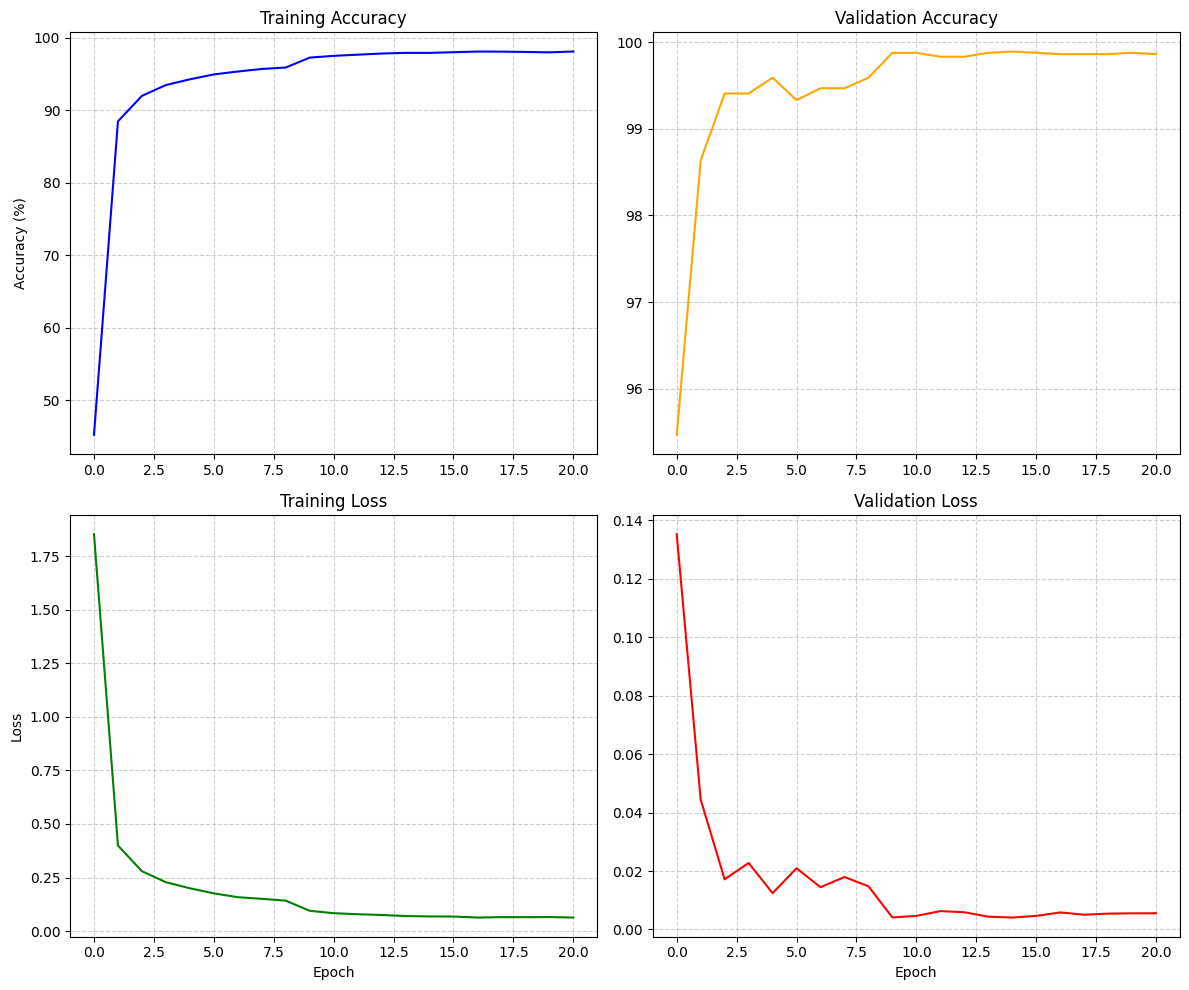

In [29]:
vcpi_util.show_history_2x2(history_dynamic)

C:\Users\paulo\AppData\Local\Temp\ipykernel_36240\3101309227.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path))


[TEST DATASET | CLASSIFICATION ACCURACY]: 99.02%
Dynamic Augmentation Confusion Matrix:


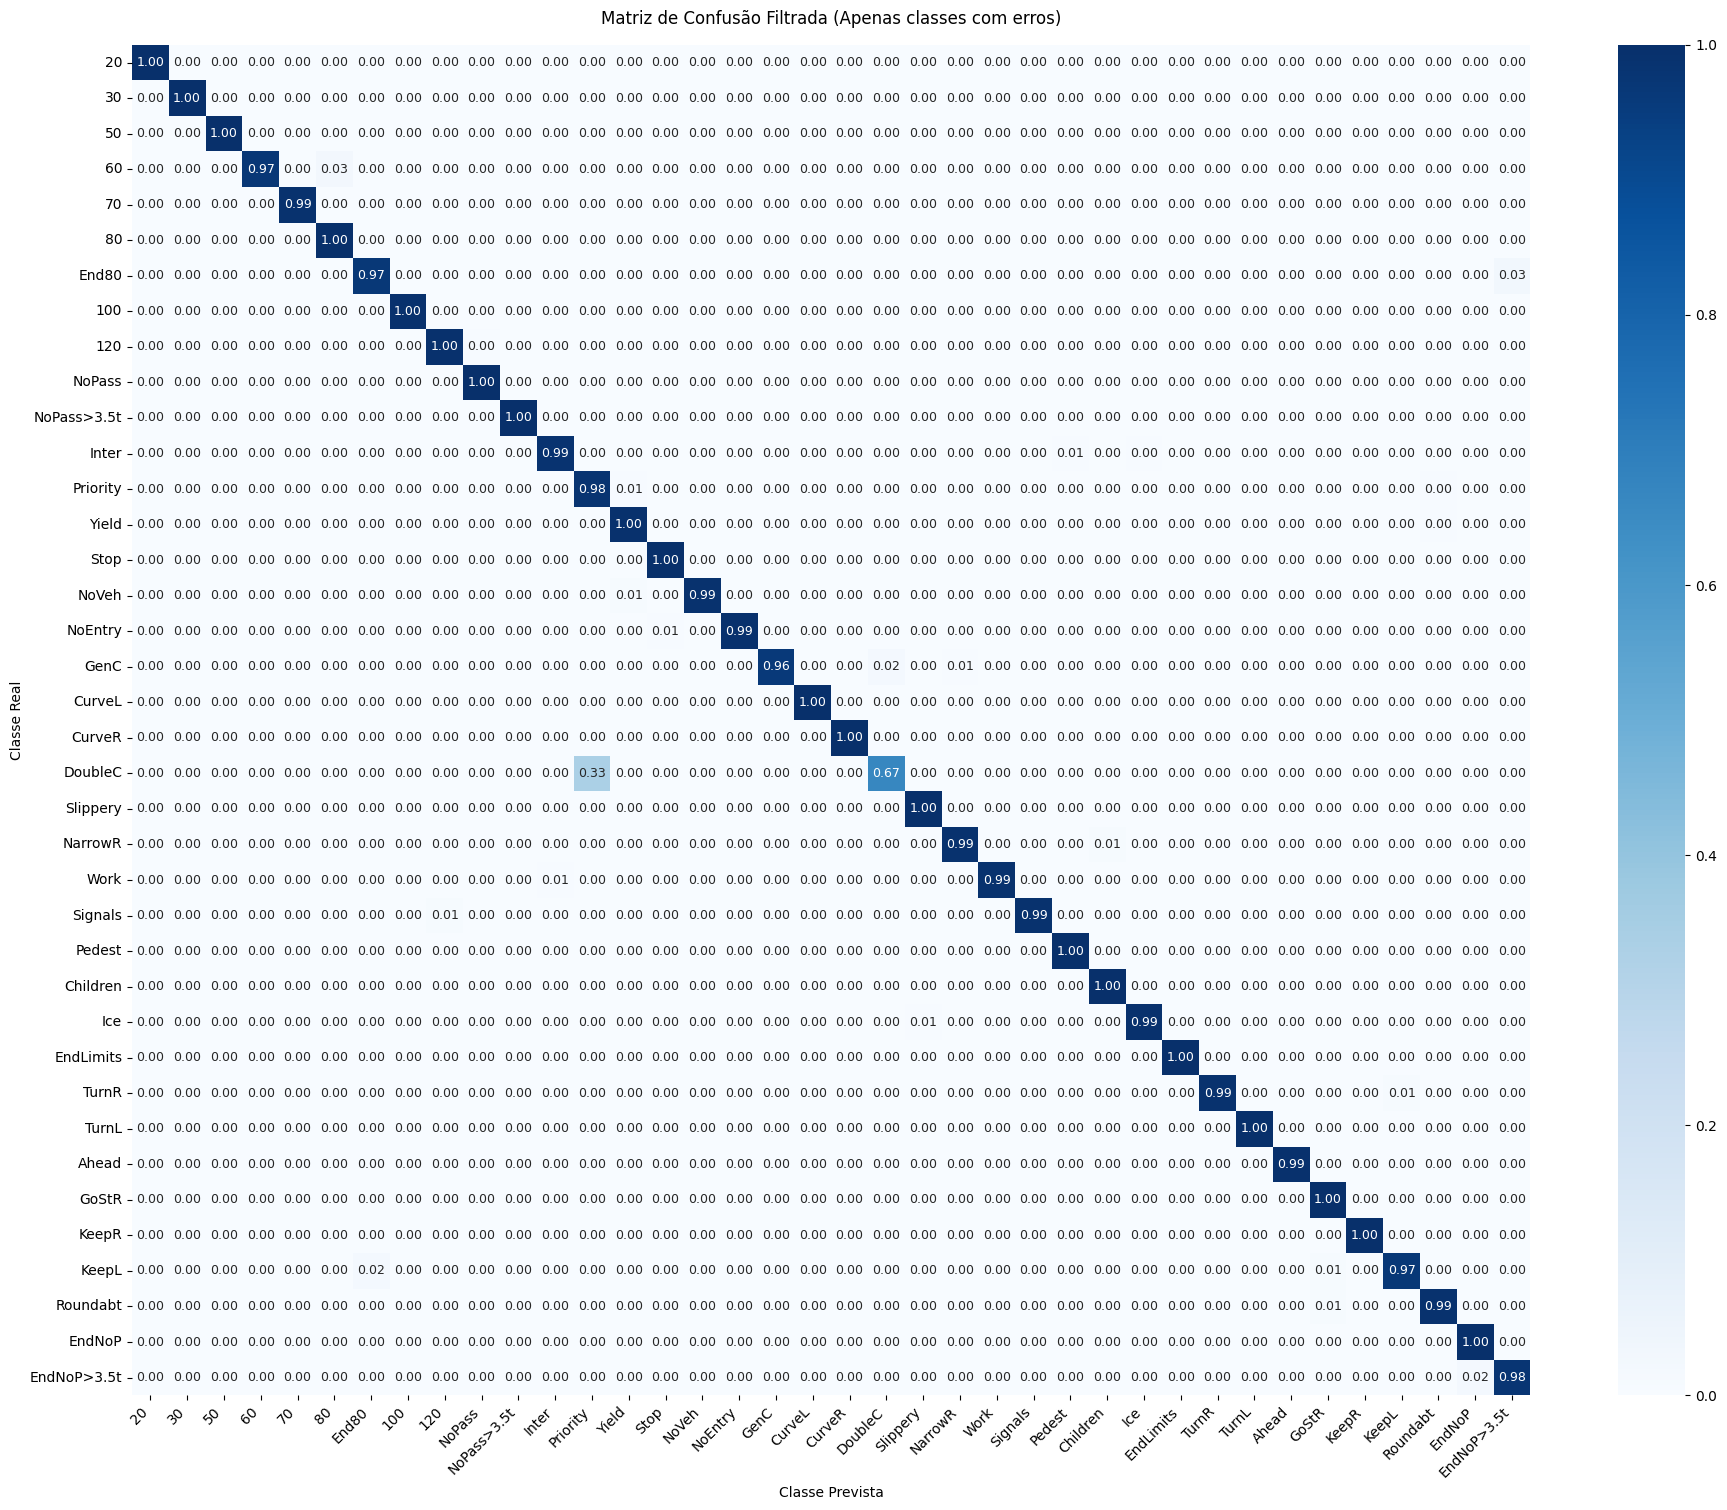

In [45]:
test_loader_dynamic = torch.utils.data.DataLoader(
    test_set_dynamic,
    batch_size=BATCH_SIZE,
    shuffle=False
)

targets_dynamic, preds_dynamic = evaluate_test_set(
    model_dynamic,
    test_loader_dynamic,
    device,
    'baseline_dynamic_best.pt'
)

print("Dynamic Augmentation Confusion Matrix:")
vcpi_util.show_filtered_confusion_matrix(targets_dynamic, preds_dynamic, classes)

## Dynamic Simples - sem pré processamento

In this variant, dynamic augmentation was applied directly on top of the statically balanced dataset, without any additional offline pre-processing transformations. The goal is to isolate the contribution of online augmentation alone, removing the variability introduced by the static pipeline.

In [31]:
# Dynamic ONLY - sem aumentar o tamanho do dataset
dynamic_only_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(degrees=10, translate=[0.05, 0.05]),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, hue=0.1),
    transforms.ToTensor()
])

train_set_dynamic_only = datasets.ImageFolder(
    root=PATH_TRAIN_BALANCED,  
    transform=dynamic_only_transform
)
train_loader_dynamic_only = torch.utils.data.DataLoader(
    train_set_dynamic_only, batch_size=BATCH_SIZE, shuffle=True
)

Epoch 001: Loss: 1.6384, Acc: 52.58%, Val Loss: 0.0498, Val Acc: 98.54%, Time: 59.46s
Epoch 002: Loss: 0.3321, Acc: 90.61%, Val Loss: 0.0316, Val Acc: 98.83%, Time: 60.89s
Epoch 003: Loss: 0.2404, Acc: 93.21%, Val Loss: 0.0208, Val Acc: 99.29%, Time: 62.50s
Epoch 004: Loss: 0.2066, Acc: 94.28%, Val Loss: 0.0128, Val Acc: 99.61%, Time: 63.74s
Epoch 005: Loss: 0.1777, Acc: 94.98%, Val Loss: 0.0090, Val Acc: 99.70%, Time: 63.29s
Epoch 006: Loss: 0.1604, Acc: 95.44%, Val Loss: 0.0090, Val Acc: 99.82%, Time: 63.03s
Epoch 007: Loss: 0.1516, Acc: 95.70%, Val Loss: 0.0198, Val Acc: 99.47%, Time: 63.35s
Epoch 008: Loss: 0.1410, Acc: 96.03%, Val Loss: 0.0208, Val Acc: 99.51%, Time: 62.91s
Epoch 009: Loss: 0.1357, Acc: 96.20%, Val Loss: 0.0236, Val Acc: 99.44%, Time: 63.18s
Epoch 010: Loss: 0.1300, Acc: 96.34%, Val Loss: 0.0089, Val Acc: 99.70%, Time: 63.28s
Epoch 011: Loss: 0.1198, Acc: 96.60%, Val Loss: 0.0164, Val Acc: 99.53%, Time: 62.69s
Epoch 012: Loss: 0.1201, Acc: 96.59%, Val Loss: 0.0089

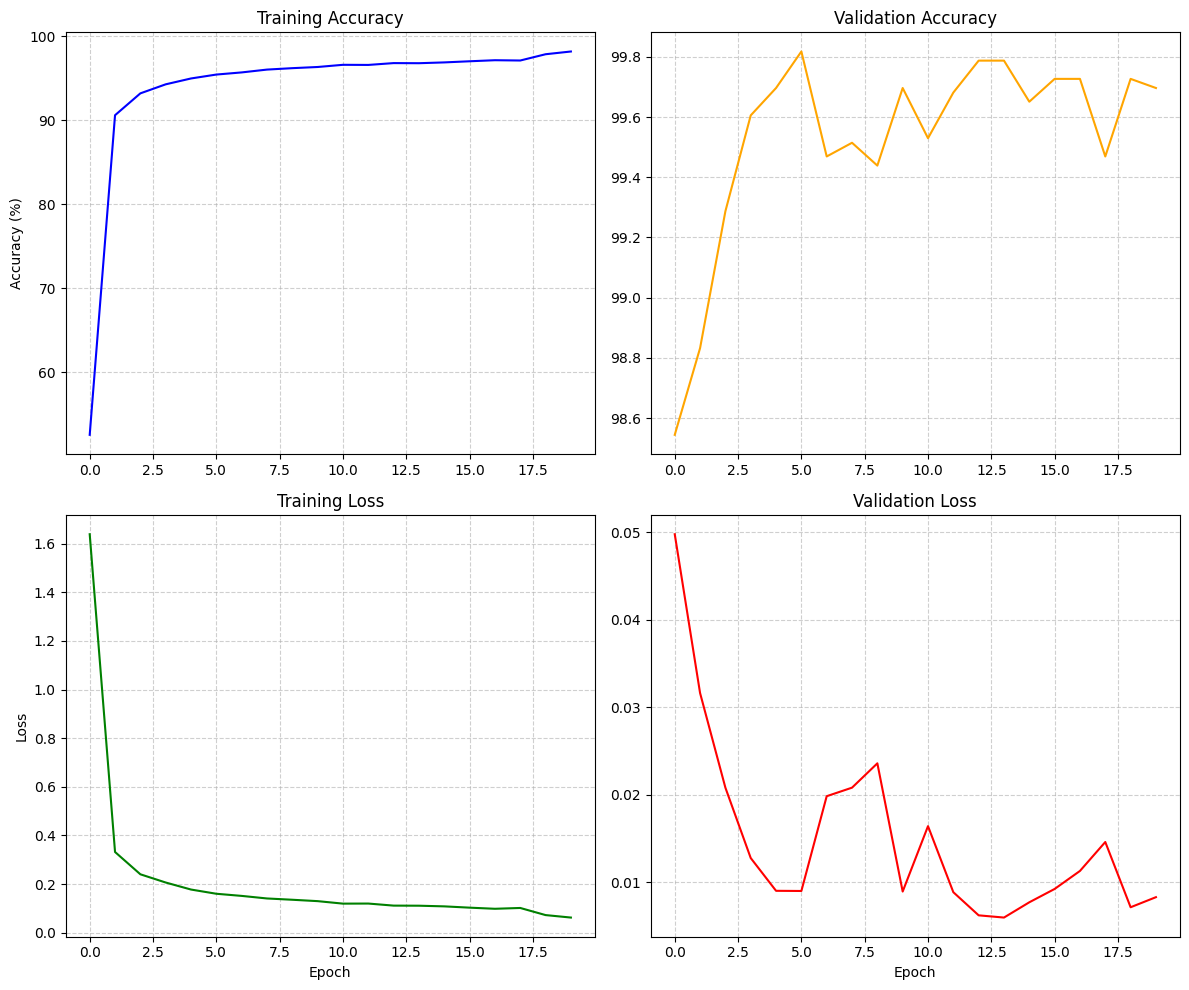

C:\Users\paulo\AppData\Local\Temp\ipykernel_36240\3101309227.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path))


[TEST DATASET | CLASSIFICATION ACCURACY]: 99.08%


In [32]:
model_dynamic_only = RobustCNN(len(classes))
optimizer_dynamic_only = torch.optim.Adam(model_dynamic_only.parameters(), lr=LEARNING_RATE)
scheduler_dynamic_only = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_dynamic_only, mode='min', factor=0.1, patience=3)
early_stopper_dynamic_only = Early_Stopping(patience=5)

history_dynamic_only = train_model(
    model_dynamic_only,
    train_loader_dynamic_only,
    val_loader,           # val sem augmentation - avaliação justa
    EPOCHS,
    loss_fn,
    optimizer_dynamic_only,
    scheduler_dynamic_only,
    early_stopper_dynamic_only,
    device,
    save_prefix='dynamic_only'
)

vcpi_util.show_history_2x2(history_dynamic_only)

targets_dynamic_only, preds_dynamic_only = evaluate_test_set(
    model_dynamic_only,
    test_loader,          # test sem augmentation
    device,
    'dynamic_only_best.pt'
)

Dynamic Augmentation Confusion Matrix:


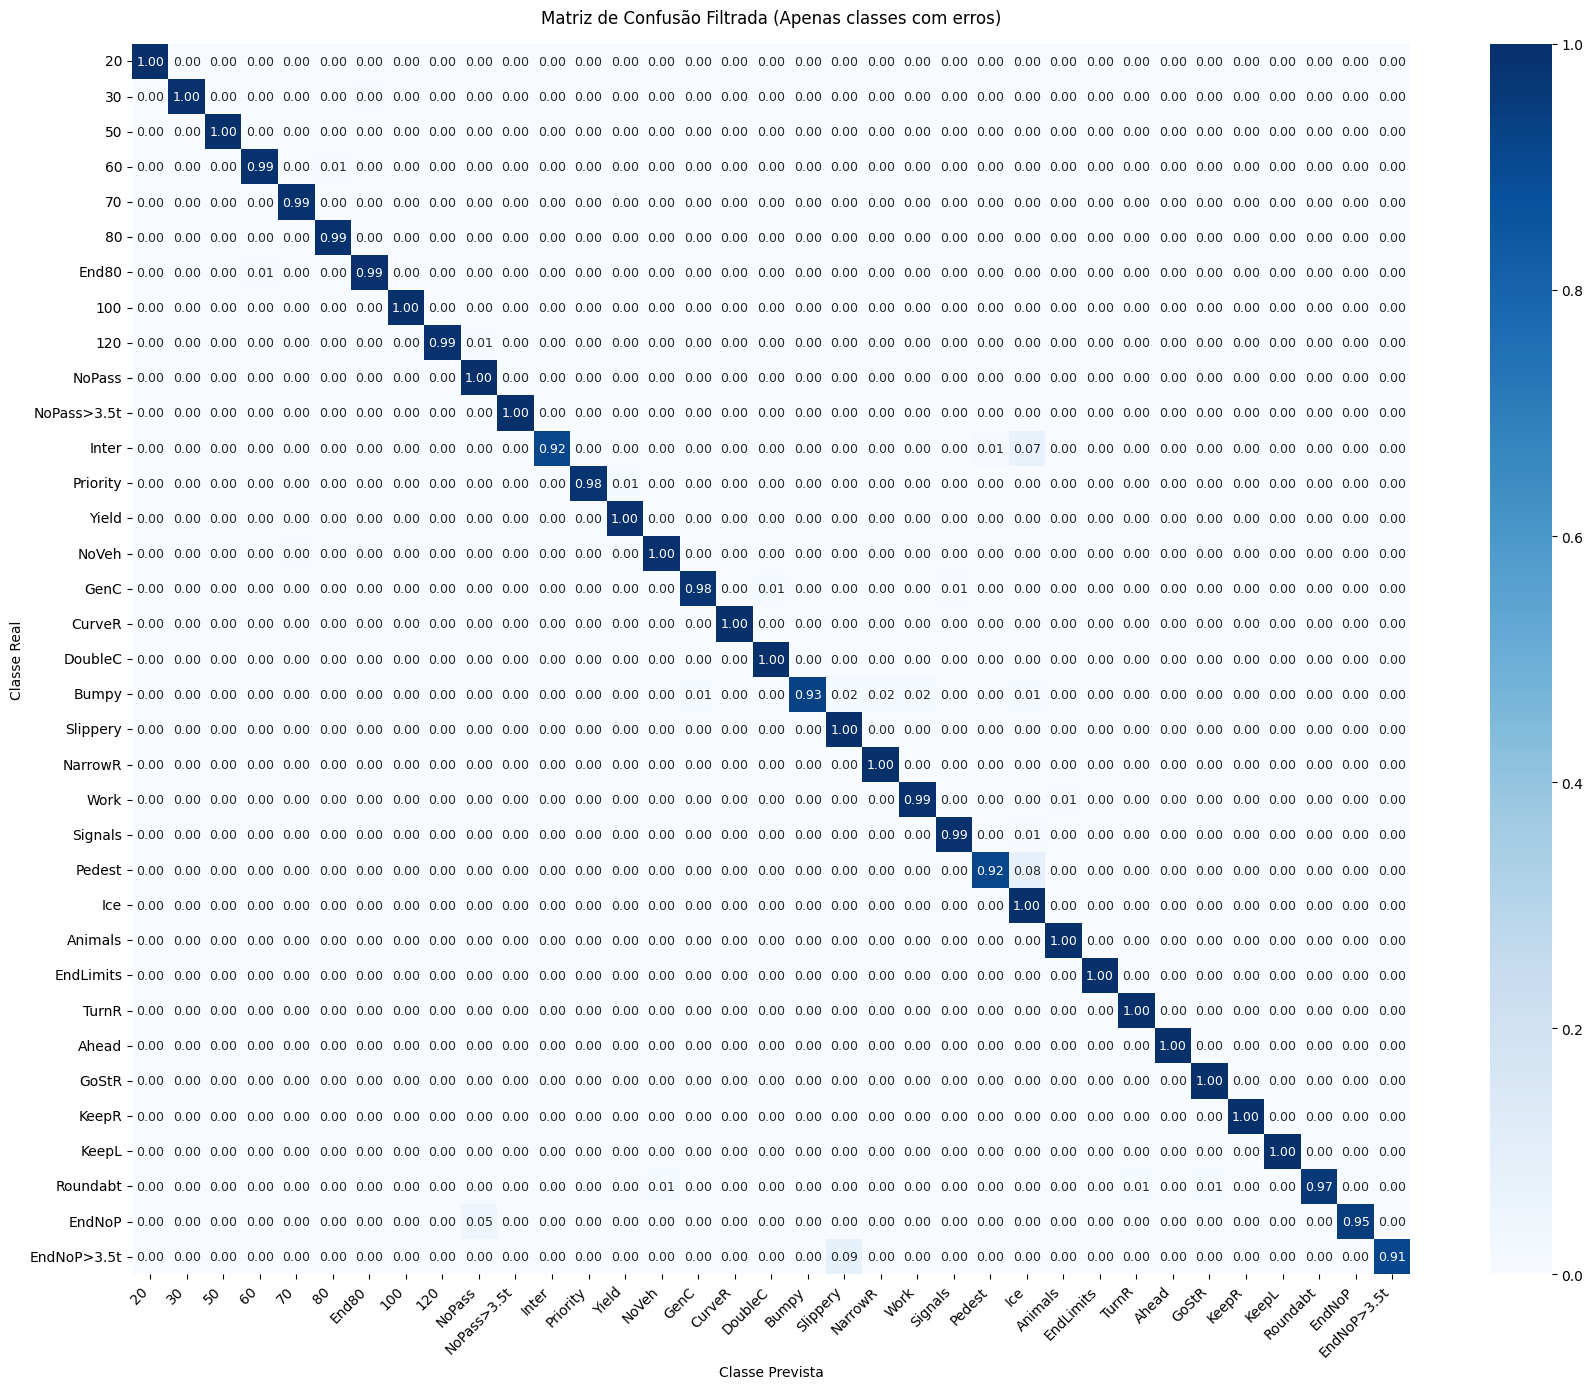

In [34]:
print("Dynamic Augmentation Confusion Matrix:")
vcpi_util.show_filtered_confusion_matrix(targets_dynamic_only, preds_dynamic_only, classes)

## Massive Dynamic data augmentation 

To explore the upper bound of dynamic augmentation, we constructed a training dataset four times larger by combining four distinct transformation pipelines via `ConcatDataset`. Each pipeline isolates a different dimension of variability: geometric transformations, brightness variation, contrast variation, and hue variation.

In [35]:
# 4 transforms diferentes combinadas via ConcatDataset -> 4x mais dados
transform_A = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(degrees=10, translate=[0.05, 0.05]),
    transforms.ToTensor()
])
transform_B = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(degrees=10, translate=[0.05, 0.05]),
    transforms.ColorJitter(brightness=0.5),
    transforms.ToTensor()
])
transform_C = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(degrees=10, translate=[0.05, 0.05]),
    transforms.ColorJitter(contrast=0.5),
    transforms.ToTensor()
])
transform_D = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(degrees=10, translate=[0.05, 0.05]),
    transforms.ColorJitter(hue=0.1),
    transforms.ToTensor()
])

train_loader_massive_dynamic = torch.utils.data.DataLoader(
    torch.utils.data.ConcatDataset([
        datasets.ImageFolder(root=PATH_TRAIN_BALANCED, transform=transform_A),
        datasets.ImageFolder(root=PATH_TRAIN_BALANCED, transform=transform_B),
        datasets.ImageFolder(root=PATH_TRAIN_BALANCED, transform=transform_C),
        datasets.ImageFolder(root=PATH_TRAIN_BALANCED, transform=transform_D),
    ]),
    batch_size=BATCH_SIZE,
    shuffle=True
)

Epoch 001: Loss: 0.5746, Acc: 83.46%, Val Loss: 0.0321, Val Acc: 99.03%, Time: 197.87s
Epoch 002: Loss: 0.1199, Acc: 96.57%, Val Loss: 0.0116, Val Acc: 99.59%, Time: 194.82s
Epoch 003: Loss: 0.0907, Acc: 97.38%, Val Loss: 0.0098, Val Acc: 99.73%, Time: 195.52s


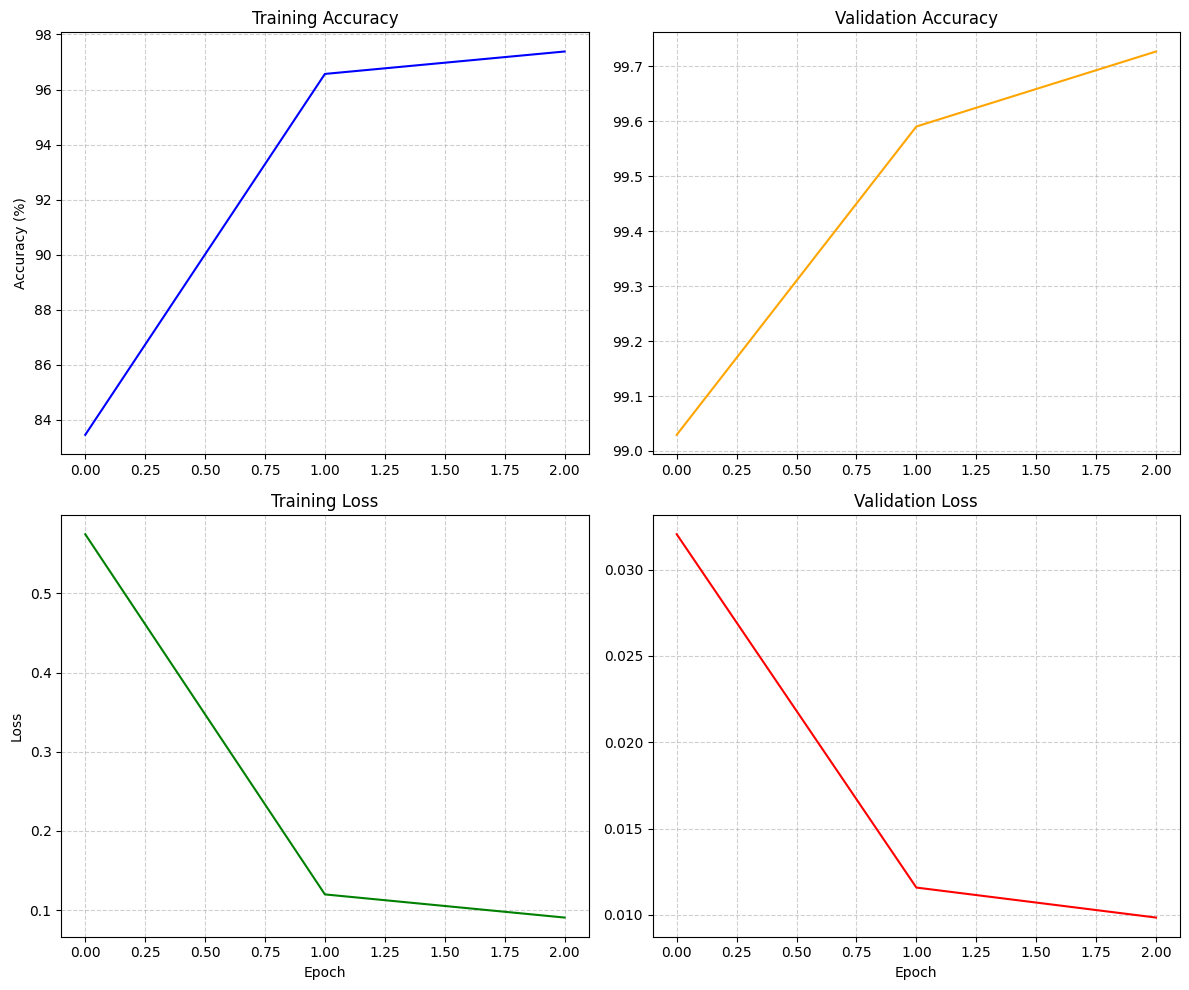

C:\Users\paulo\AppData\Local\Temp\ipykernel_36240\3101309227.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path))


[TEST DATASET | CLASSIFICATION ACCURACY]: 98.93%


In [ ]:
model_massive = RobustCNN(len(classes))
optimizer_massive = torch.optim.Adam(model_massive.parameters(), lr=LEARNING_RATE)
scheduler_massive = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_massive, mode='min', factor=0.1, patience=3)
early_stopper_massive = Early_Stopping(patience=5)

history_massive = train_model(
    model_massive,
    train_loader_massive_dynamic,
    val_loader,
    EPOCHS,
    loss_fn,
    optimizer_massive,
    scheduler_massive,
    early_stopper_massive,
    device,
    save_prefix='massive_dynamic'
)

vcpi_util.show_history_2x2(history_massive)

targets_massive, preds_massive = evaluate_test_set(
    model_massive,
    test_loader,
    device,
    'massive_dynamic_best.pt'
)

Dynamic Augmentation Confusion Matrix:


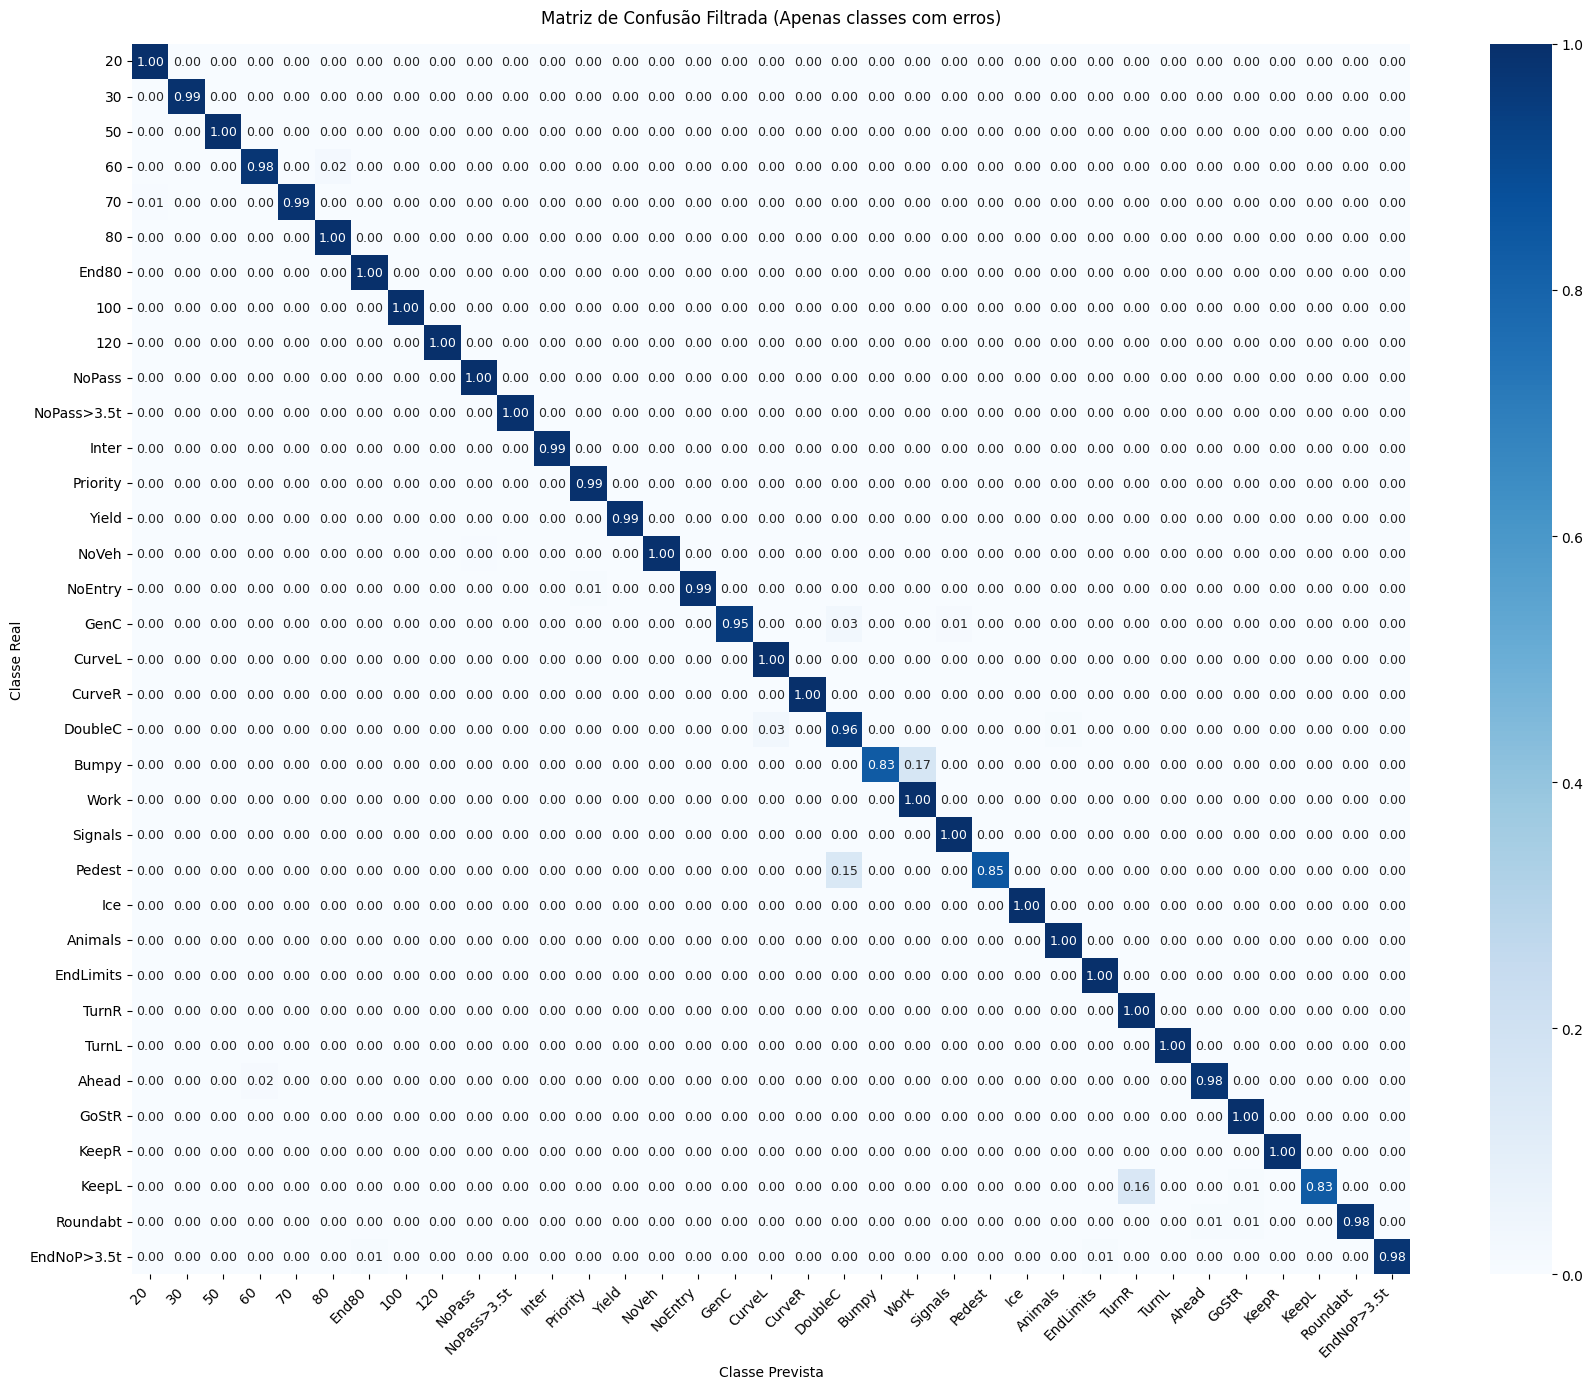

In [37]:
print("Dynamic Augmentation Confusion Matrix:")

vcpi_util.show_filtered_confusion_matrix(targets_massive, preds_massive, classes)

In [40]:
print("Final validation accuracy (static only):", history_baseline['val_acc'][-1])
print("Best validation accuracy (static only):", max(history_baseline['val_acc']))
targets, preds = evaluate_test_set(model_baseline, test_loader, device, 'baseline_best.pt')
print(" --- ")

print("Final validation accuracy (static only) ROBUST:", history_robust['val_acc'][-1])
print("Best validation accuracy (static only) ROBUST", max(history_robust['val_acc']))
targets_robust, preds_robust = evaluate_test_set(
    model_robust, 
    test_loader, 
    device, 
    'robust_best.pt'
)
print(" --- ")

print("Final validation accuracy (static + dynamic):", history_dynamic['val_acc'][-1])
print("Best validation accuracy (static + dynamic):", max(history_dynamic['val_acc']))
targets_dynamic, preds_dynamic = evaluate_test_set(
    model_dynamic,
    test_loader_dynamic,
    device,
    'baseline_dynamic_best.pt'
)
print(" --- ")

print("Final valid  b ation accuracy (dynamic):", history_dynamic_only ['val_acc'][-1])
print("Best validation accuracy (dynamic):", max(history_dynamic_only ['val_acc']))
targets_dynamic_only, preds_dynamic_only = evaluate_test_set(
    model_dynamic_only,
    test_loader,          # test sem augmentation
    device,
    'dynamic_only_best.pt'
)
print(" --- ")

print("Final validation accuracy (massive dynamic):", history_massive ['val_acc'][-1])
print("Best validation accuracy (massive dynamic):", max(history_massive ['val_acc']))
targets_massive, preds_massive = evaluate_test_set(
    model_massive,
    test_loader,
    device,
    'massive_dynamic_best.pt'
)

Final validation accuracy (static only): 90.32453745829542
Best validation accuracy (static only): 90.55201698513801


C:\Users\paulo\AppData\Local\Temp\ipykernel_36240\3101309227.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path))


[TEST DATASET | CLASSIFICATION ACCURACY]: 87.10%
 --- 
Final validation accuracy (static only) ROBUST: 99.86351228389445
Best validation accuracy (static only) ROBUST 99.86351228389445
[TEST DATASET | CLASSIFICATION ACCURACY]: 99.35%
 --- 
Final validation accuracy (static + dynamic): 99.86351228389445
Best validation accuracy (static + dynamic): 99.89384288747345
[TEST DATASET | CLASSIFICATION ACCURACY]: 99.02%
 --- 
Final valid  b ation accuracy (dynamic): 99.69669396420989
Best validation accuracy (dynamic): 99.81801637852594
[TEST DATASET | CLASSIFICATION ACCURACY]: 99.08%
 --- 
Final validation accuracy (massive dynamic): 99.7270245677889
Best validation accuracy (massive dynamic): 99.7270245677889
[TEST DATASET | CLASSIFICATION ACCURACY]: 98.93%


## Conclusion (3 run median)   

Final validation accuracy (static only): 90.32  
Best validation accuracy (static only): 90.55  
\[TEST DATASET | CLASSIFICATION ACCURACY]: 87.12%  

Final validation accuracy (static only) ROBUST: 99.86  
Best validation accuracy (static only) ROBUST 99.86  
\[TEST DATASET | CLASSIFICATION ACCURACY]: 99.39%  

Final validation accuracy (static + dynamic): 99.86  
Best validation accuracy (static + dynamic): 99.89  
\[TEST DATASET | CLASSIFICATION ACCURACY]: 99.00%  

Final valid  b ation accuracy (dynamic): 99.69  
Best validation accuracy (dynamic): 99.81  
\[TEST DATASET | CLASSIFICATION ACCURACY]: 99.07%  

Final validation accuracy (massive dynamic): 99.72  
Best validation accuracy (massive dynamic): 99.72  
\[TEST DATASET | CLASSIFICATION ACCURACY]: 98.80%  

# Phase 3 (cont.): Classical Image Processing Techniques

Beyond standard data augmentation, classical image processing methods can be applied as 
preprocessing steps to improve the model's robustness to real-world conditions specific 
to traffic sign recognition.

We explore three techniques particularly relevant to the GTSRB dataset:

* **CLAHE (Contrast Limited Adaptive Histogram Equalization):** Enhances local contrast 
  by equalizing histograms in small image regions rather than globally. This is especially 
  effective for signs captured under uneven lighting, shadows, or at dusk. Critically, it 
  is applied on the L channel of the LAB color space, preserving the hue and saturation 
  that carry semantic meaning in traffic signs.

* **Gamma Correction:** Compensates for over/underexposed captures by applying a non-linear 
  luminance transformation. A gamma < 1 brightens dark images; gamma > 1 darkens bright ones.
  Randomly sampling gamma during training simulates the full spectrum of lighting conditions.

* **Channel-wise Normalization (mean/std):** Standardizes each color channel to zero mean 
  and unit variance, computed from the training set. This is a fundamental preprocessing 
  step that accelerates convergence and ensures numerical stability during gradient descent.

## CLAHE + Normalização

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1200291..2.962573].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.051713..1.0816519].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0200001..2.962573].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0992824..3.0846848].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0992824..3.0846848].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0041437..2.463422].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0950431..2

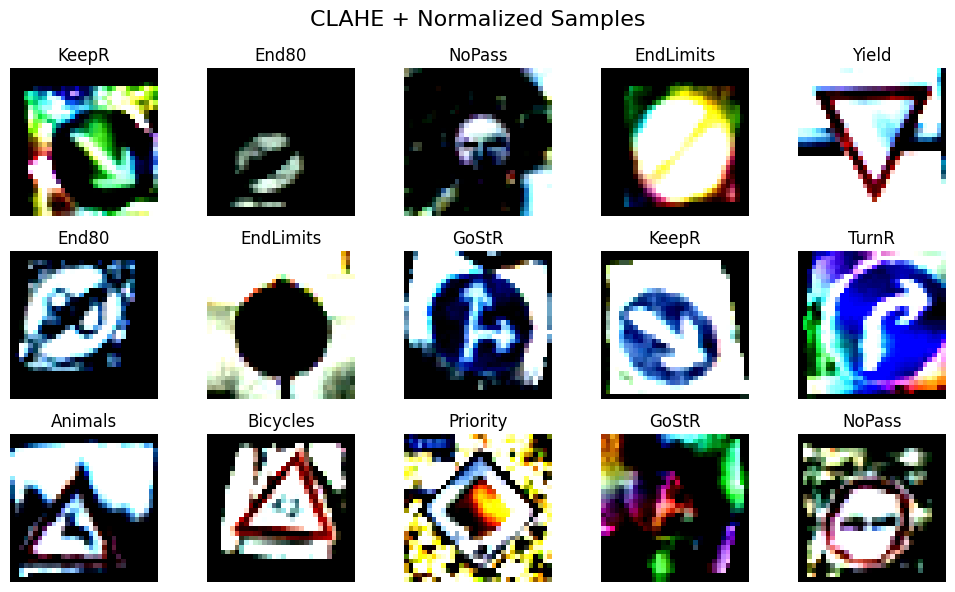

Epoch 001: Loss: 1.1239, Acc: 67.08%, Val Loss: 0.3768, Val Acc: 89.66%, Time: 61.46s
Epoch 002: Loss: 0.1771, Acc: 95.03%, Val Loss: 0.3188, Val Acc: 91.83%, Time: 61.89s
Epoch 003: Loss: 0.1260, Acc: 96.48%, Val Loss: 0.2744, Val Acc: 92.61%, Time: 60.53s
Epoch 004: Loss: 0.1001, Acc: 97.22%, Val Loss: 0.3151, Val Acc: 92.80%, Time: 61.72s
Epoch 005: Loss: 0.0827, Acc: 97.63%, Val Loss: 0.2666, Val Acc: 93.68%, Time: 61.95s
Epoch 006: Loss: 0.0729, Acc: 97.99%, Val Loss: 0.3256, Val Acc: 92.01%, Time: 62.04s
Epoch 007: Loss: 0.0609, Acc: 98.26%, Val Loss: 0.2002, Val Acc: 95.09%, Time: 61.95s
Epoch 008: Loss: 0.0580, Acc: 98.36%, Val Loss: 0.2016, Val Acc: 94.80%, Time: 61.42s
Epoch 009: Loss: 0.0516, Acc: 98.59%, Val Loss: 0.2575, Val Acc: 94.46%, Time: 61.41s
Epoch 010: Loss: 0.0504, Acc: 98.61%, Val Loss: 0.1717, Val Acc: 95.66%, Time: 61.19s
Epoch 011: Loss: 0.0437, Acc: 98.78%, Val Loss: 0.1612, Val Acc: 95.88%, Time: 61.45s
Epoch 012: Loss: 0.0418, Acc: 98.82%, Val Loss: 0.1643

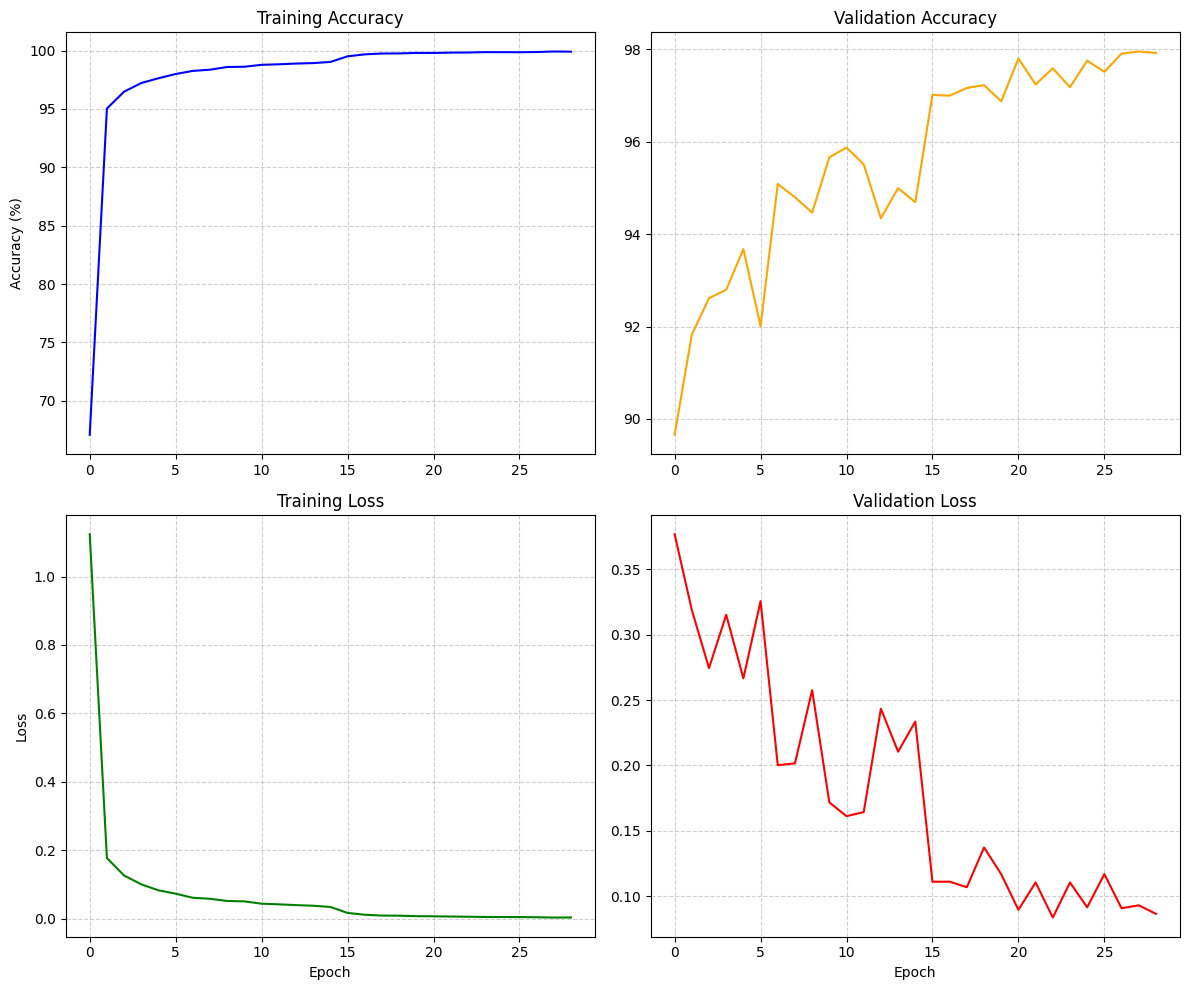

C:\Users\paulo\AppData\Local\Temp\ipykernel_36240\3101309227.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path))


[TEST DATASET | CLASSIFICATION ACCURACY]: 98.34%


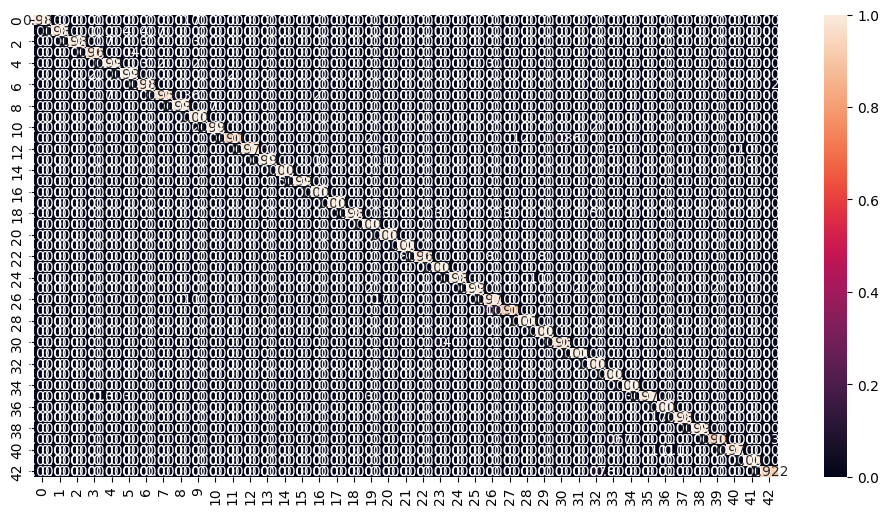

In [43]:
def get_mean_std(dataset):
    """
    Computes the per-channel mean and standard deviation of a dataset.
    Used to normalize images to zero mean and unit variance before training.
    """
    loader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=False)
    mean = torch.zeros(3)
    std  = torch.zeros(3)
    for imgs, _ in loader:
        for c in range(3):
            mean[c] += imgs[:, c, :, :].mean()
            std[c]  += imgs[:, c, :, :].std()
    mean /= len(loader)
    std  /= len(loader)
    return mean, std

mean, std = get_mean_std(train_set_balanced)

transform_clahe_norm = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    our_util.CLAHE_Transform(clip_limit=2.0, tile_size=(4, 4)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

transform_eval_norm = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_set_clahe     = datasets.ImageFolder(root=PATH_TRAIN_BALANCED, transform=transform_clahe_norm)
val_set_clahe       = datasets.ImageFolder(root=PATH_VAL,            transform=transform_eval_norm)
test_set_clahe      = datasets.ImageFolder(root=PATH_TEST,           transform=transform_eval_norm)

train_loader_clahe  = torch.utils.data.DataLoader(train_set_clahe,  batch_size=BATCH_SIZE, shuffle=True)
val_loader_clahe    = torch.utils.data.DataLoader(val_set_clahe,    batch_size=BATCH_SIZE, shuffle=False)
test_loader_clahe   = torch.utils.data.DataLoader(test_set_clahe,   batch_size=BATCH_SIZE, shuffle=False)

our_util.show_random_samples(train_set_clahe, classes, "CLAHE + Normalized Samples")

model_clahe         = RobustCNN(len(classes))
optimizer_clahe     = torch.optim.Adam(model_clahe.parameters(), lr=LEARNING_RATE)
scheduler_clahe     = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_clahe, mode='min', factor=0.1, patience=3)
early_stopper_clahe = Early_Stopping(patience=5)

history_clahe = train_model(
    model_clahe,
    train_loader_clahe,
    val_loader_clahe,
    EPOCHS,
    loss_fn,
    optimizer_clahe,
    scheduler_clahe,
    early_stopper_clahe,
    device,
    save_prefix='clahe_norm'
)

vcpi_util.show_history_2x2(history_clahe)

targets_clahe, preds_clahe = evaluate_test_set(
    model_clahe, test_loader_clahe, device, 'clahe_norm_best.pt'
)

vcpi_util.show_confusion_matrix(targets_clahe, preds_clahe, len(classes))

## CLAHE + Normalização + dynamic augmentation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1785645..1.7272576].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1785645..1.8676609].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1785645..3.0846848].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1785645..1.4329164].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0834259..1.8658718].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1785645..2.0748913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.178564

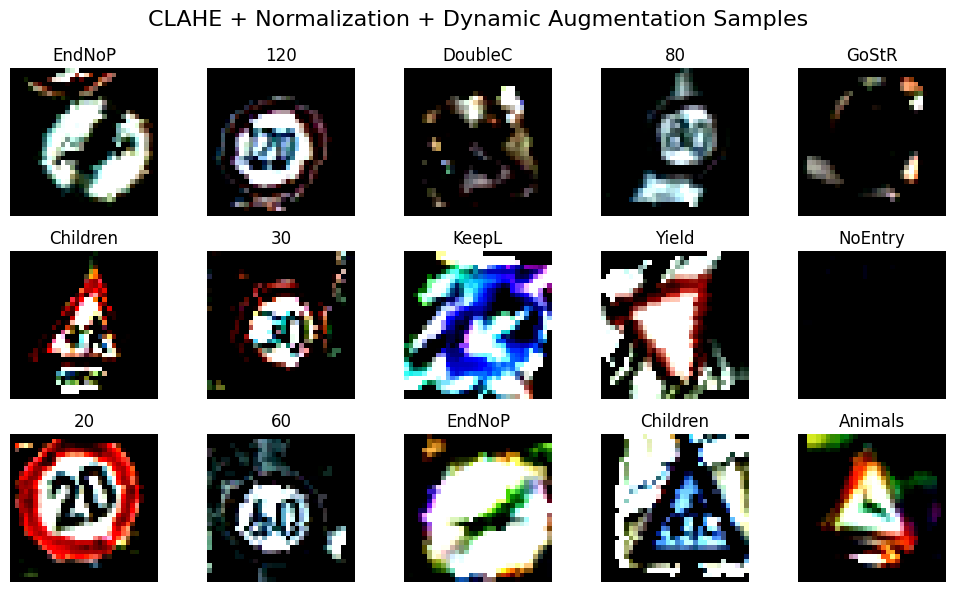

Epoch 001: Loss: 1.5085, Acc: 55.60%, Val Loss: 0.3079, Val Acc: 91.63%, Time: 98.83s
Epoch 002: Loss: 0.3640, Acc: 89.61%, Val Loss: 0.1502, Val Acc: 95.74%, Time: 99.85s
Epoch 003: Loss: 0.2723, Acc: 92.32%, Val Loss: 0.2167, Val Acc: 94.31%, Time: 99.32s


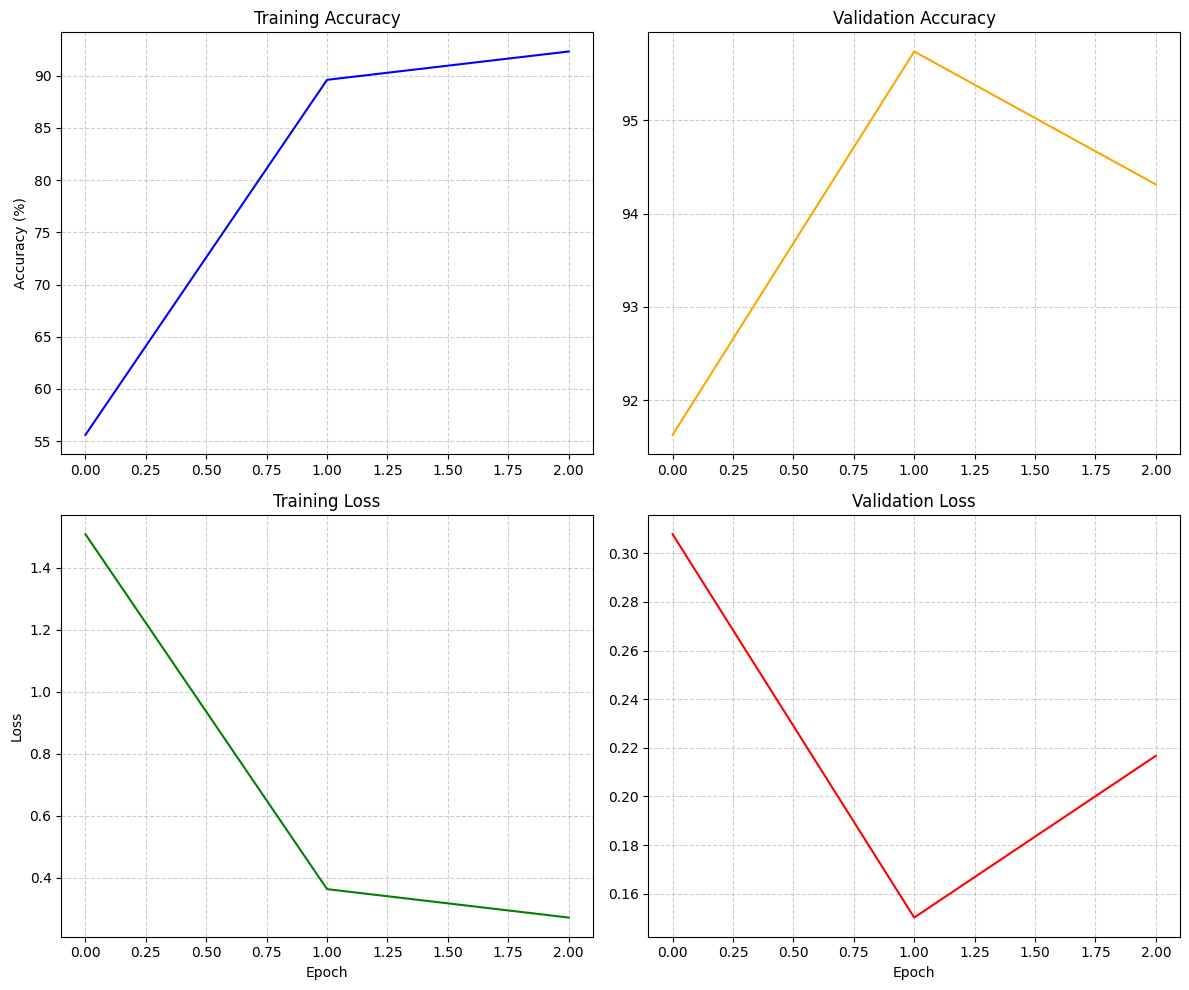

C:\Users\paulo\AppData\Local\Temp\ipykernel_36240\3101309227.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path))


[TEST DATASET | CLASSIFICATION ACCURACY]: 93.12%


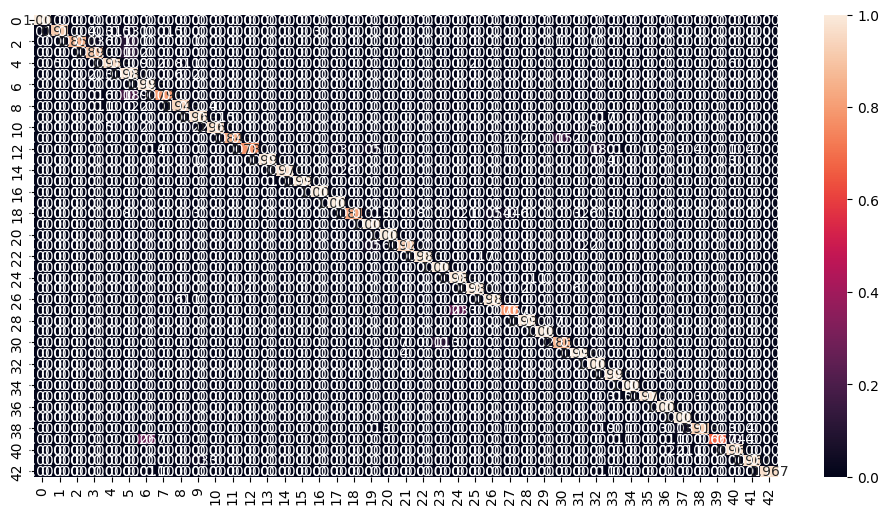

In [44]:
transform_clahe_dynamic = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    our_util.CLAHE_Transform(clip_limit=2.0, tile_size=(4, 4)),
    our_util.GammaCorrection(gamma_range=(0.6, 1.8)),
    transforms.RandomRotation(12),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.08, 0.08),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_set_clahe_dyn    = datasets.ImageFolder(root=PATH_TRAIN_BALANCED, transform=transform_clahe_dynamic)
train_loader_clahe_dyn = torch.utils.data.DataLoader(train_set_clahe_dyn, batch_size=BATCH_SIZE, shuffle=True)

our_util.show_random_samples(train_set_clahe_dyn, classes, "CLAHE + Normalization + Dynamic Augmentation Samples")

model_clahe_dyn         = RobustCNN(len(classes))
optimizer_clahe_dyn     = torch.optim.Adam(model_clahe_dyn.parameters(), lr=LEARNING_RATE)
scheduler_clahe_dyn     = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_clahe_dyn, mode='min', factor=0.1, patience=3)
early_stopper_clahe_dyn = Early_Stopping(patience=5)

history_clahe_dyn = train_model(
    model_clahe_dyn,
    train_loader_clahe_dyn,
    val_loader_clahe,       # same normalized eval transform
    3,
    loss_fn,
    optimizer_clahe_dyn,
    scheduler_clahe_dyn,
    early_stopper_clahe_dyn,
    device,
    save_prefix='clahe_dynamic'
)

vcpi_util.show_history_2x2(history_clahe_dyn)

targets_clahe_dyn, preds_clahe_dyn = evaluate_test_set(
    model_clahe_dyn, test_loader_clahe, device, 'clahe_dynamic_best.pt'
)
vcpi_util.show_confusion_matrix(targets_clahe_dyn, preds_clahe_dyn, len(classes))